In [2]:
import matplotlib.pyplot as plt
import numpy as np


def compute_error(actual, truth):
    return 100 * np.linalg.norm(truth - actual) / np.linalg.norm(truth)

In [24]:
def timeseries(
    *,
    n_observables: int = 8,
    n_timesteps: int = 500,
    n_modes: int = 4,
    dt: float = 0.01,
    noise_scale: float = 0.05,
    random_seed: int = 42,
) -> np.ndarray:
    rng = np.random.default_rng(random_seed)
    sigmas = rng.uniform(-0.5, -0.05, n_modes)  # decay rates
    omegas = rng.uniform(0.5, 8.0, n_modes)  # angular frequencies
    eigenvalues = np.exp((sigmas + 1j * omegas) * dt)  # (n_modes,)
    Phi_real = rng.standard_normal((n_observables, n_modes))
    Phi_imag = rng.standard_normal((n_observables, n_modes))
    Phi = Phi_real + 1j * Phi_imag  # (n_observables, n_modes)
    b = rng.standard_normal(n_modes) + 1j * rng.standard_normal(n_modes)
    t_idx = np.arange(n_timesteps)  # (n_timesteps,)
    Vand = eigenvalues[:, None] ** t_idx  # (n_modes, n_timesteps)
    X_clean = (Phi * b[None, :]) @ Vand  # (n_observables, n_timesteps)
    X_clean = X_clean.real  # take real part
    signal_std = np.std(X_clean, axis=1, keepdims=True)  # (n_observables, 1)
    noise = rng.standard_normal((n_observables, n_timesteps))
    noise *= noise_scale * signal_std
    X = X_clean + noise  # (n_observables, n_timesteps)
    return X

In [25]:
from dataclasses import dataclass, field

from pydmd import BOPDMD
from pydmd.plotter import plot_summary


class DmdResult(list):
    def plot(self):
        for i, res in self:
            plot_summary(res)


@dataclass
class Dmd:
    observables: list[str]
    t: np.ndarray
    n: int = field(init=False)
    n_timesteps: int = field(init=False)
    duration: float = field(init=False)

    def __post_init__(self):
        self.n = len(self.observables)
        self.n_timesteps = self.t.shape[0]
        self.duration = self.t[-1]

    def fit(self):
        results = DmdResult()
        for seed in range(10):
            # y.shape = (3, 22)  ← matches t.shape = (22,)
            y = timeseries(random_seed=seed, n_observables=self.n, n_timesteps=self.n_timesteps)
            dmd = BOPDMD(svd_rank=0, num_trials=50, trial_size=0.5)
            dmd.fit(y, t)
            results.append((seed, dmd))
        return results

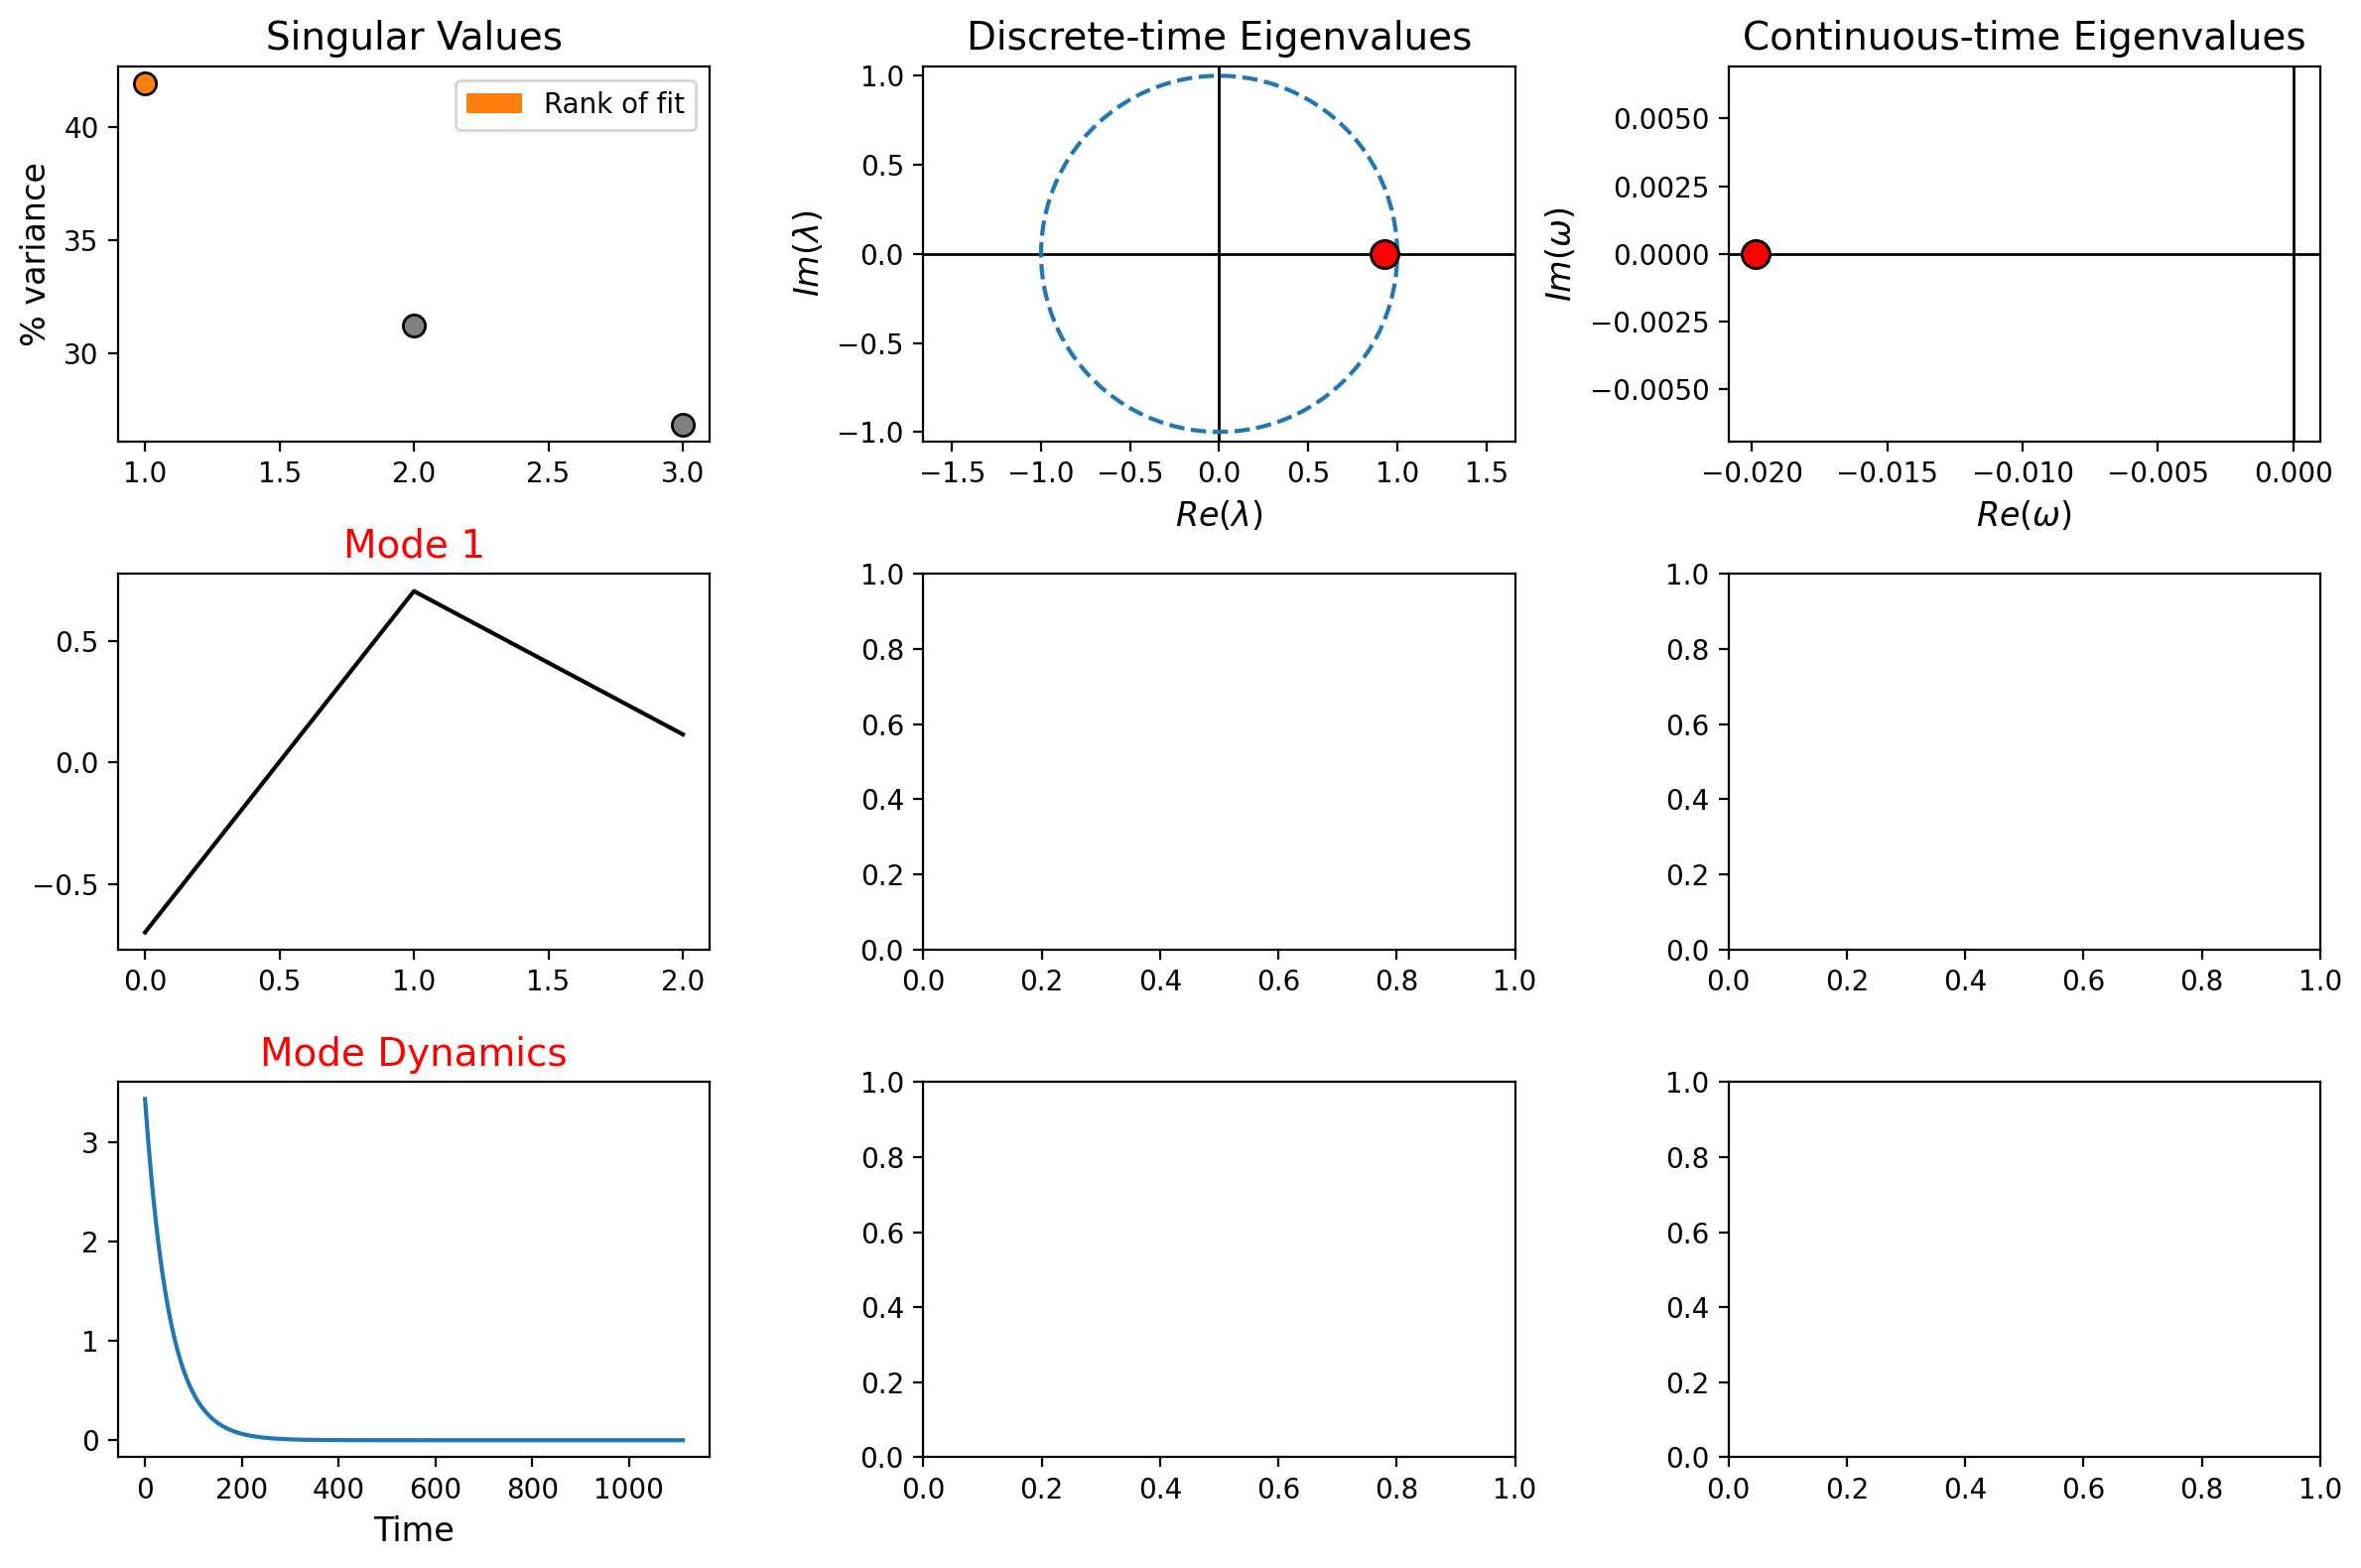

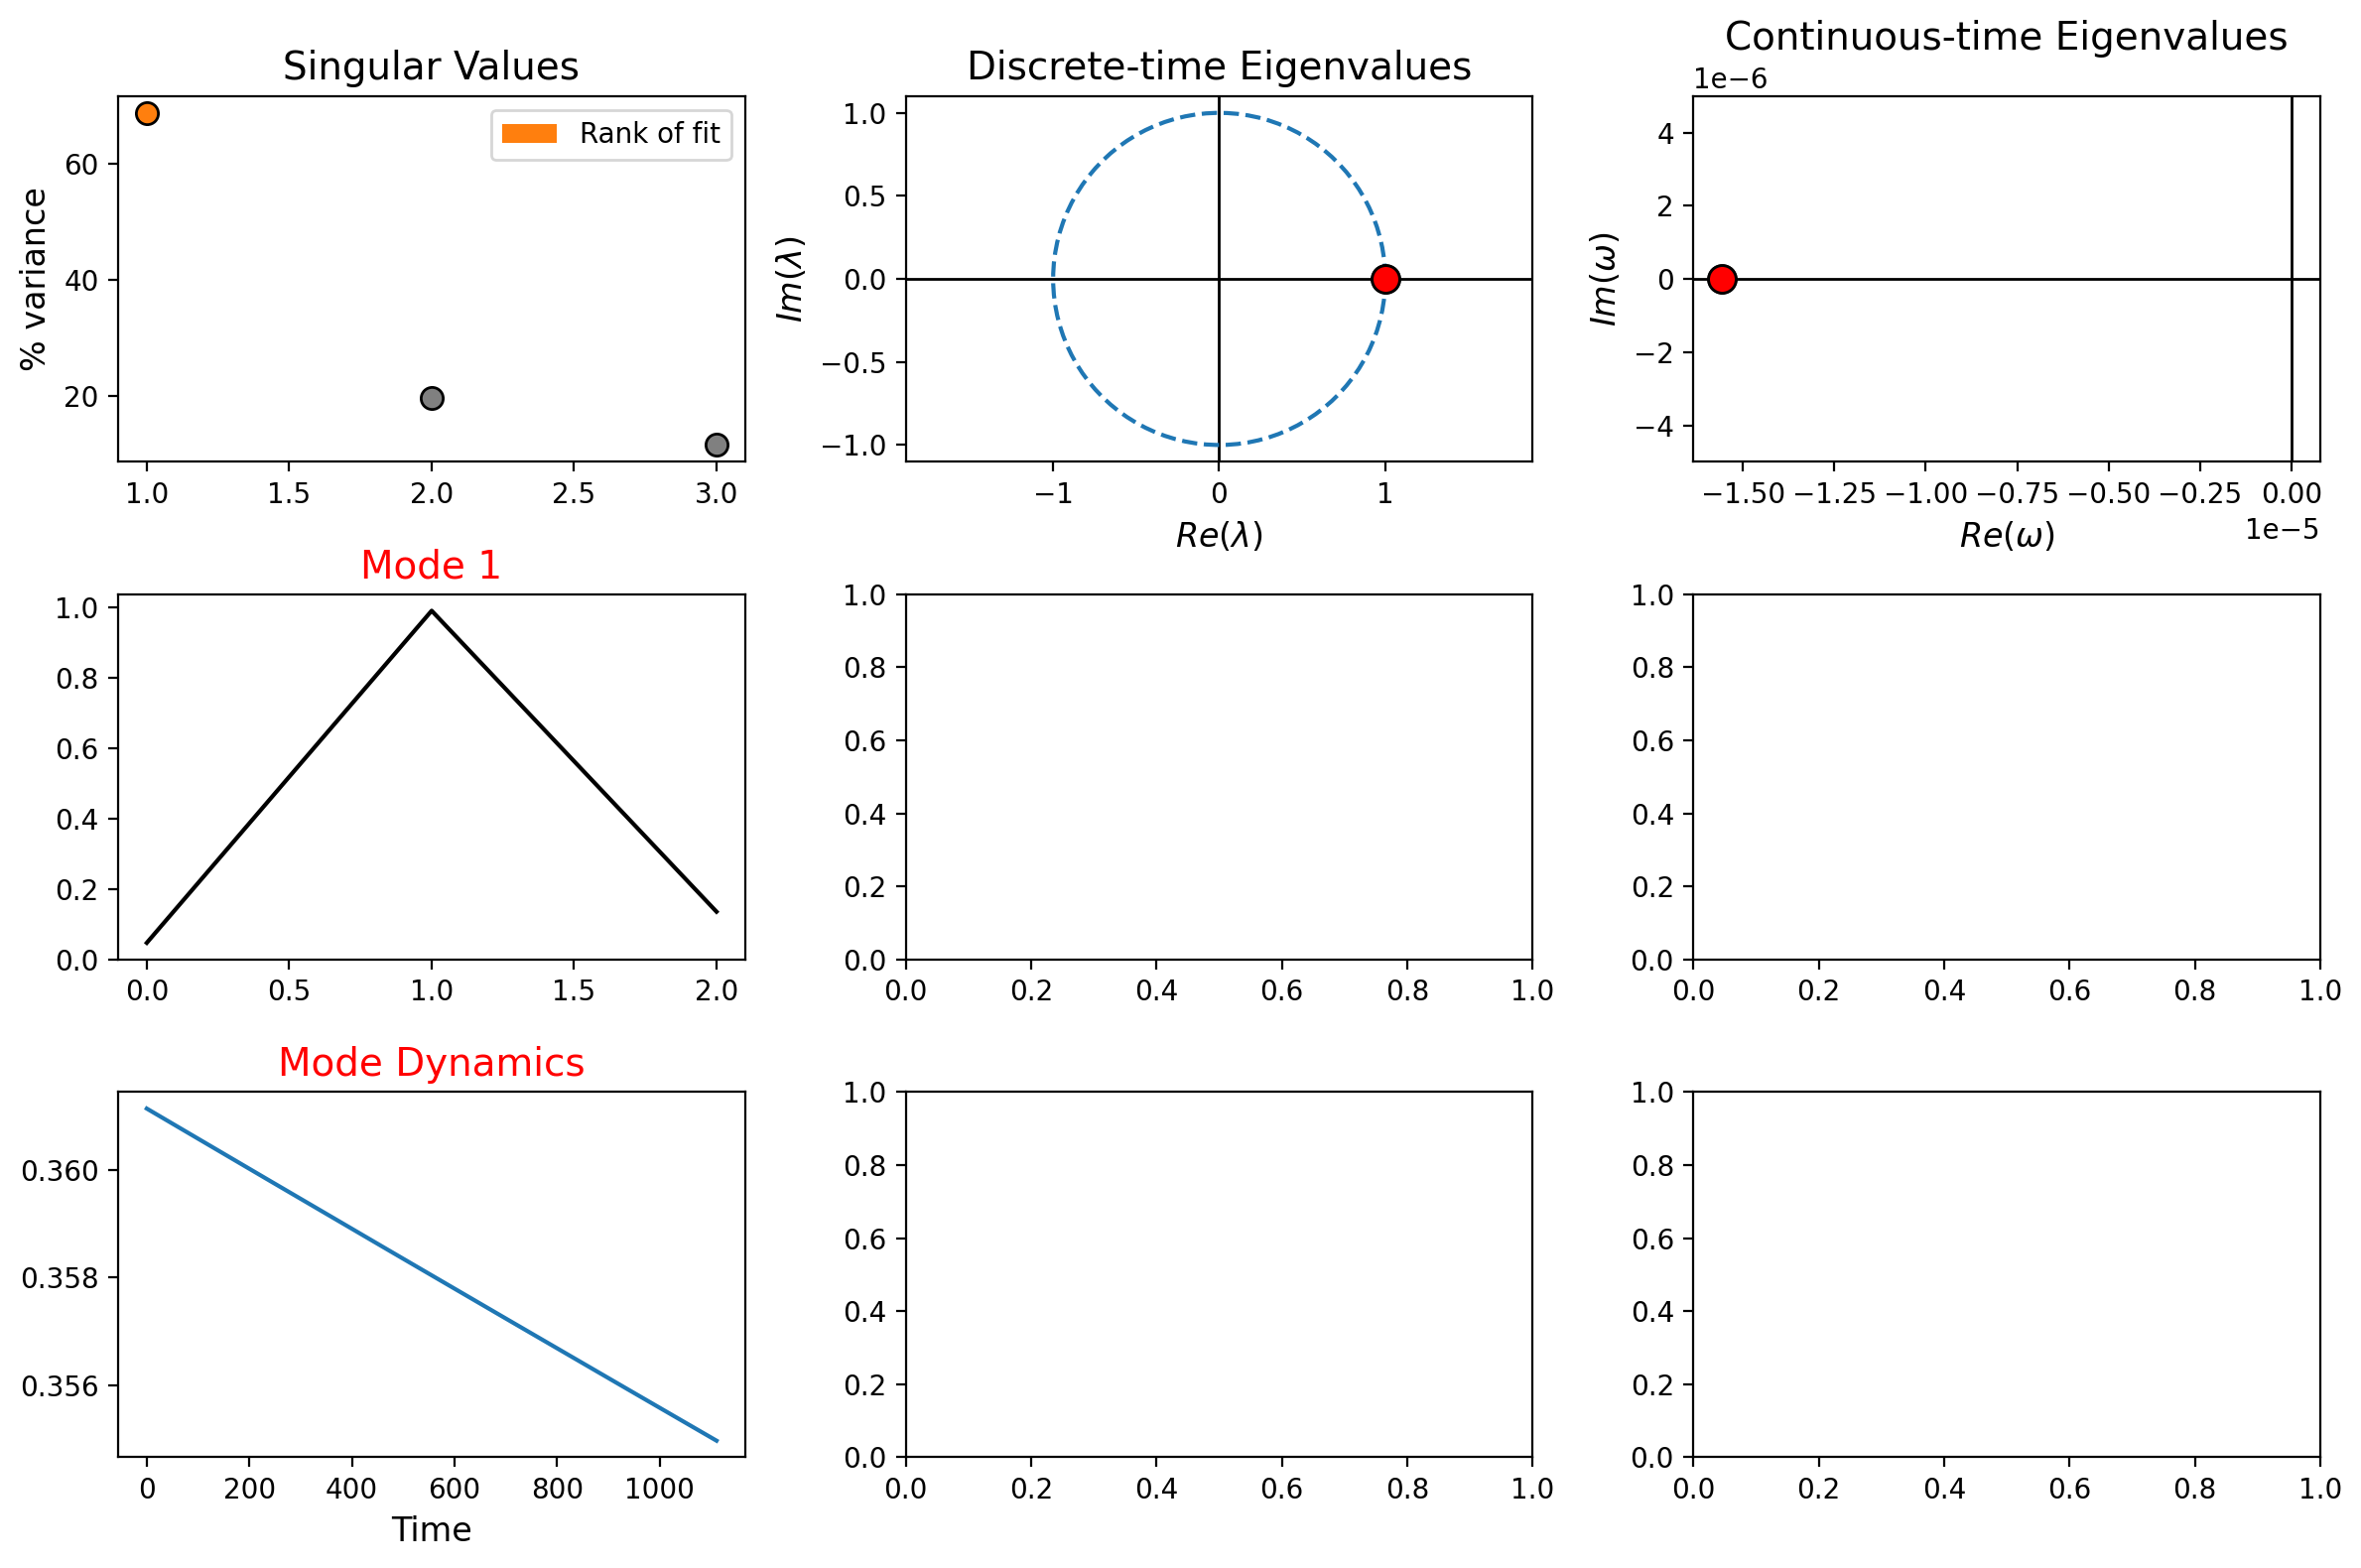

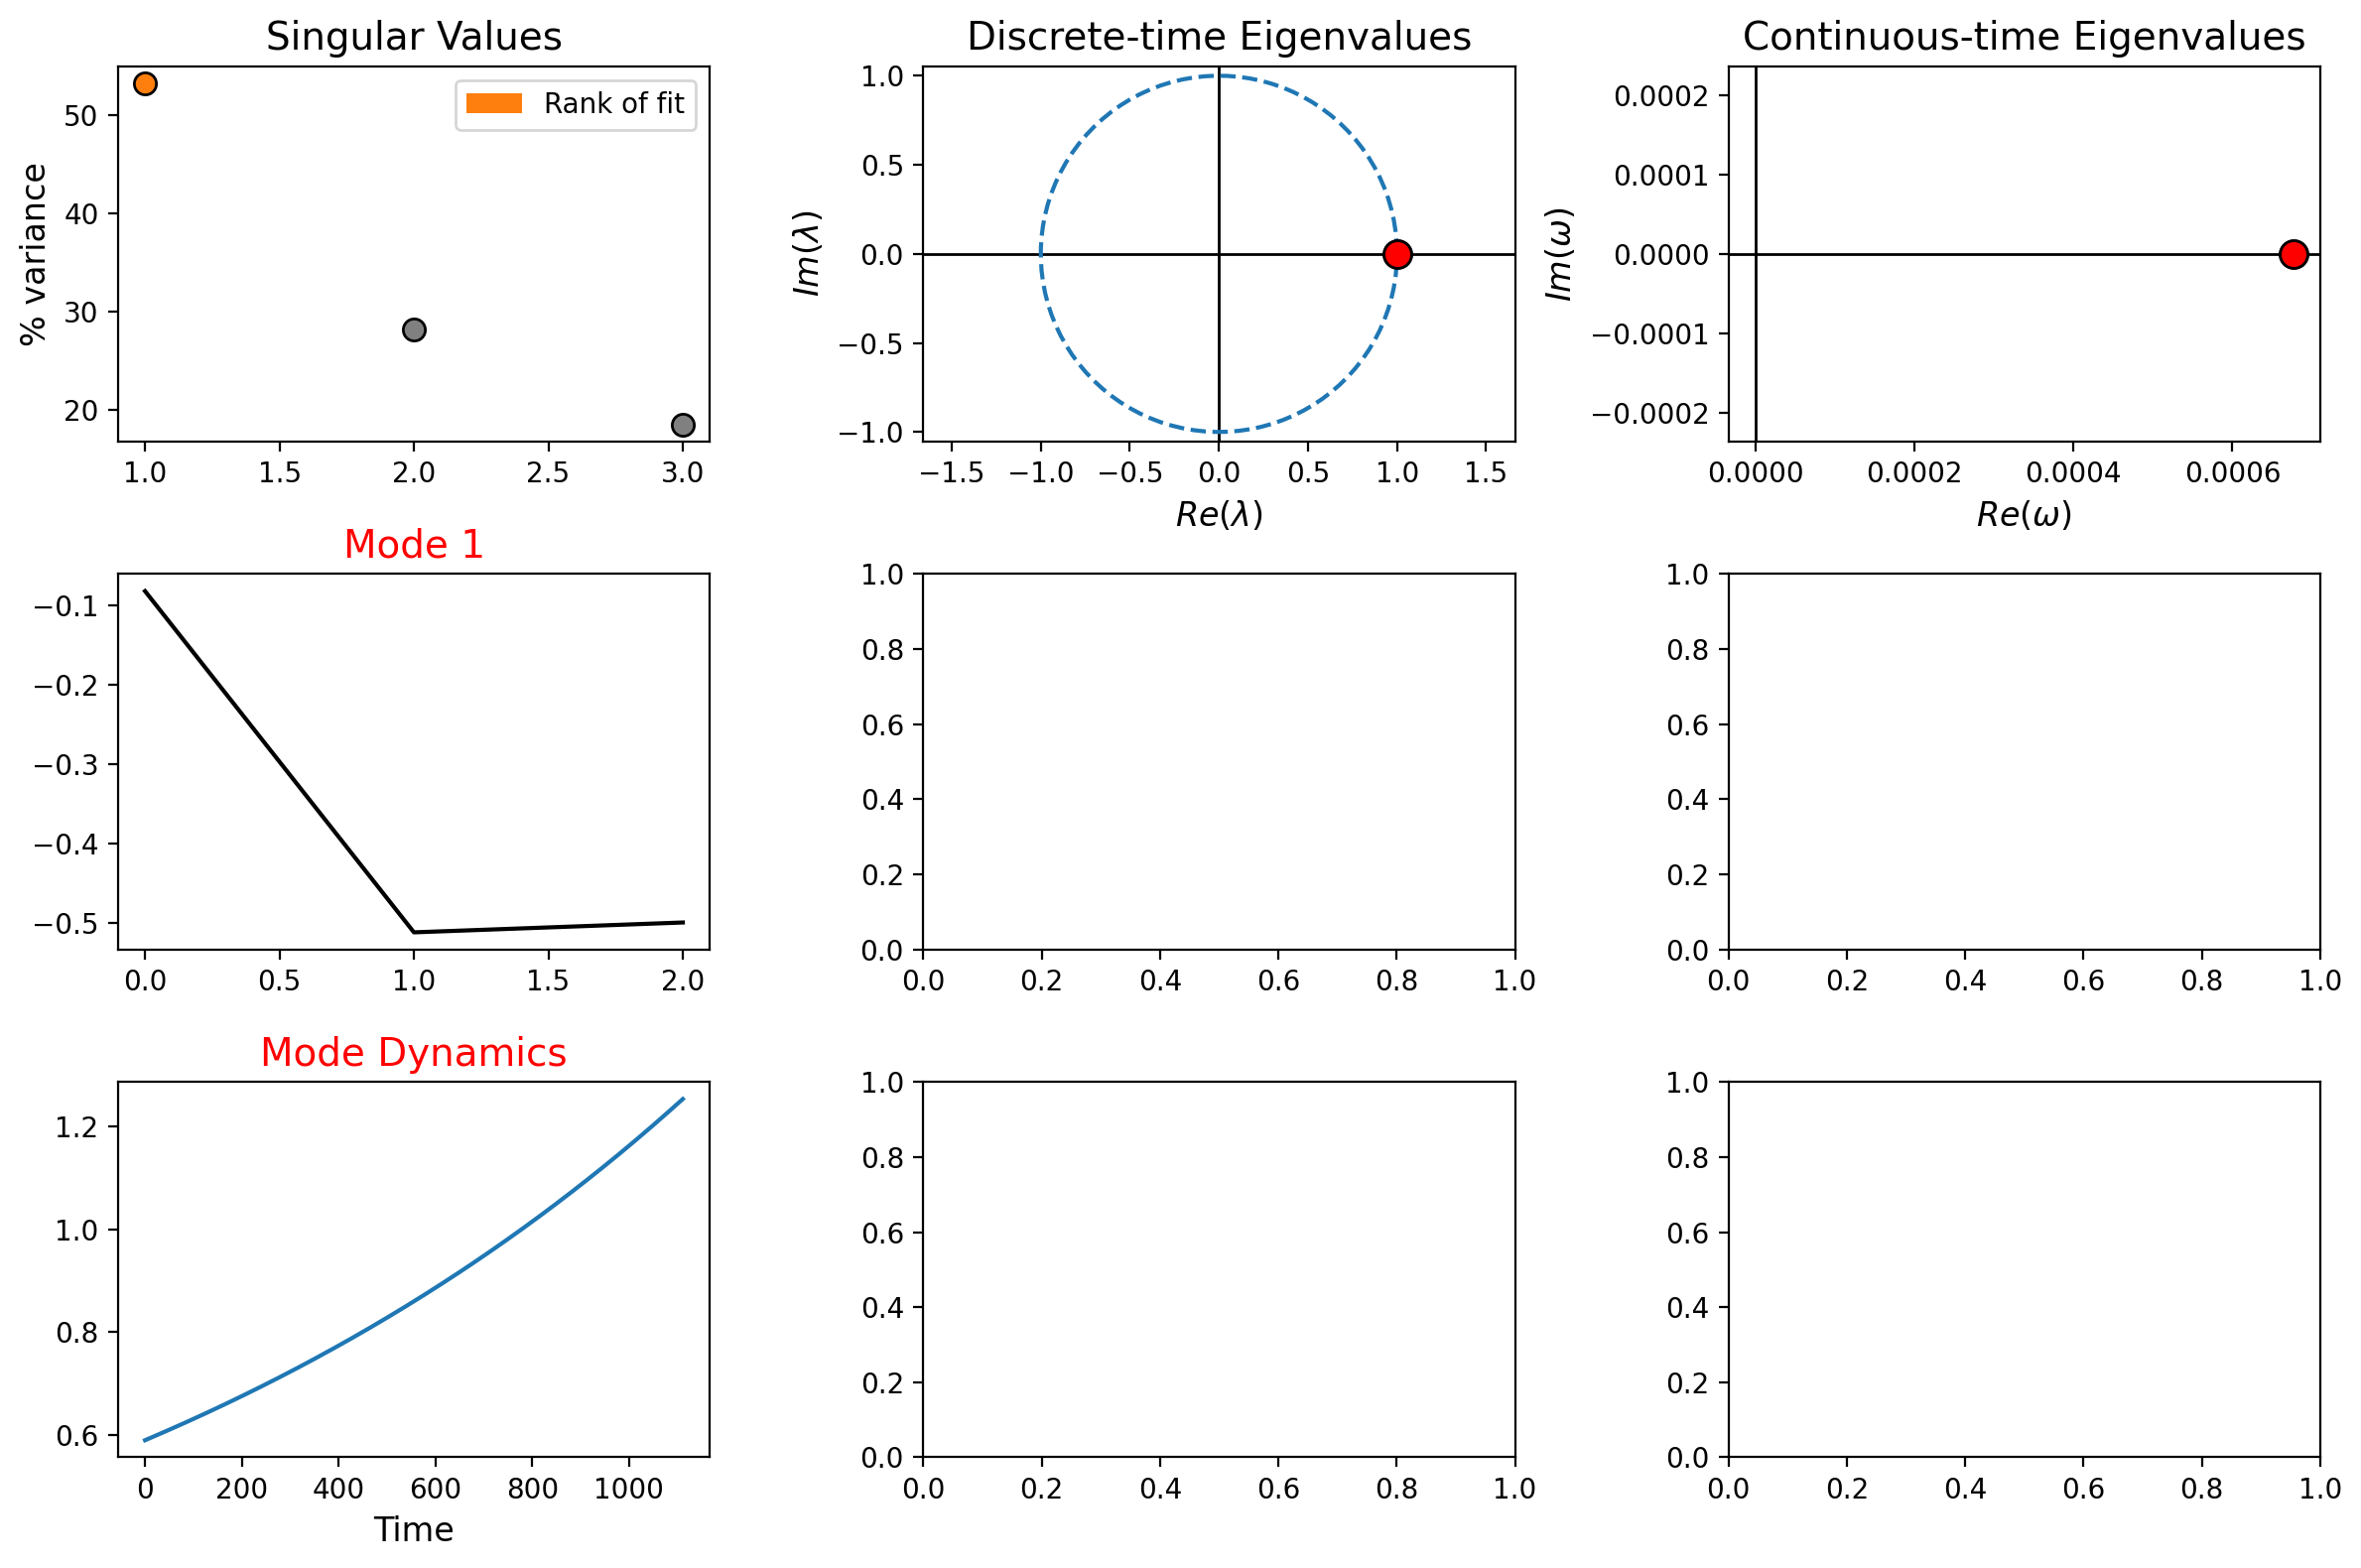

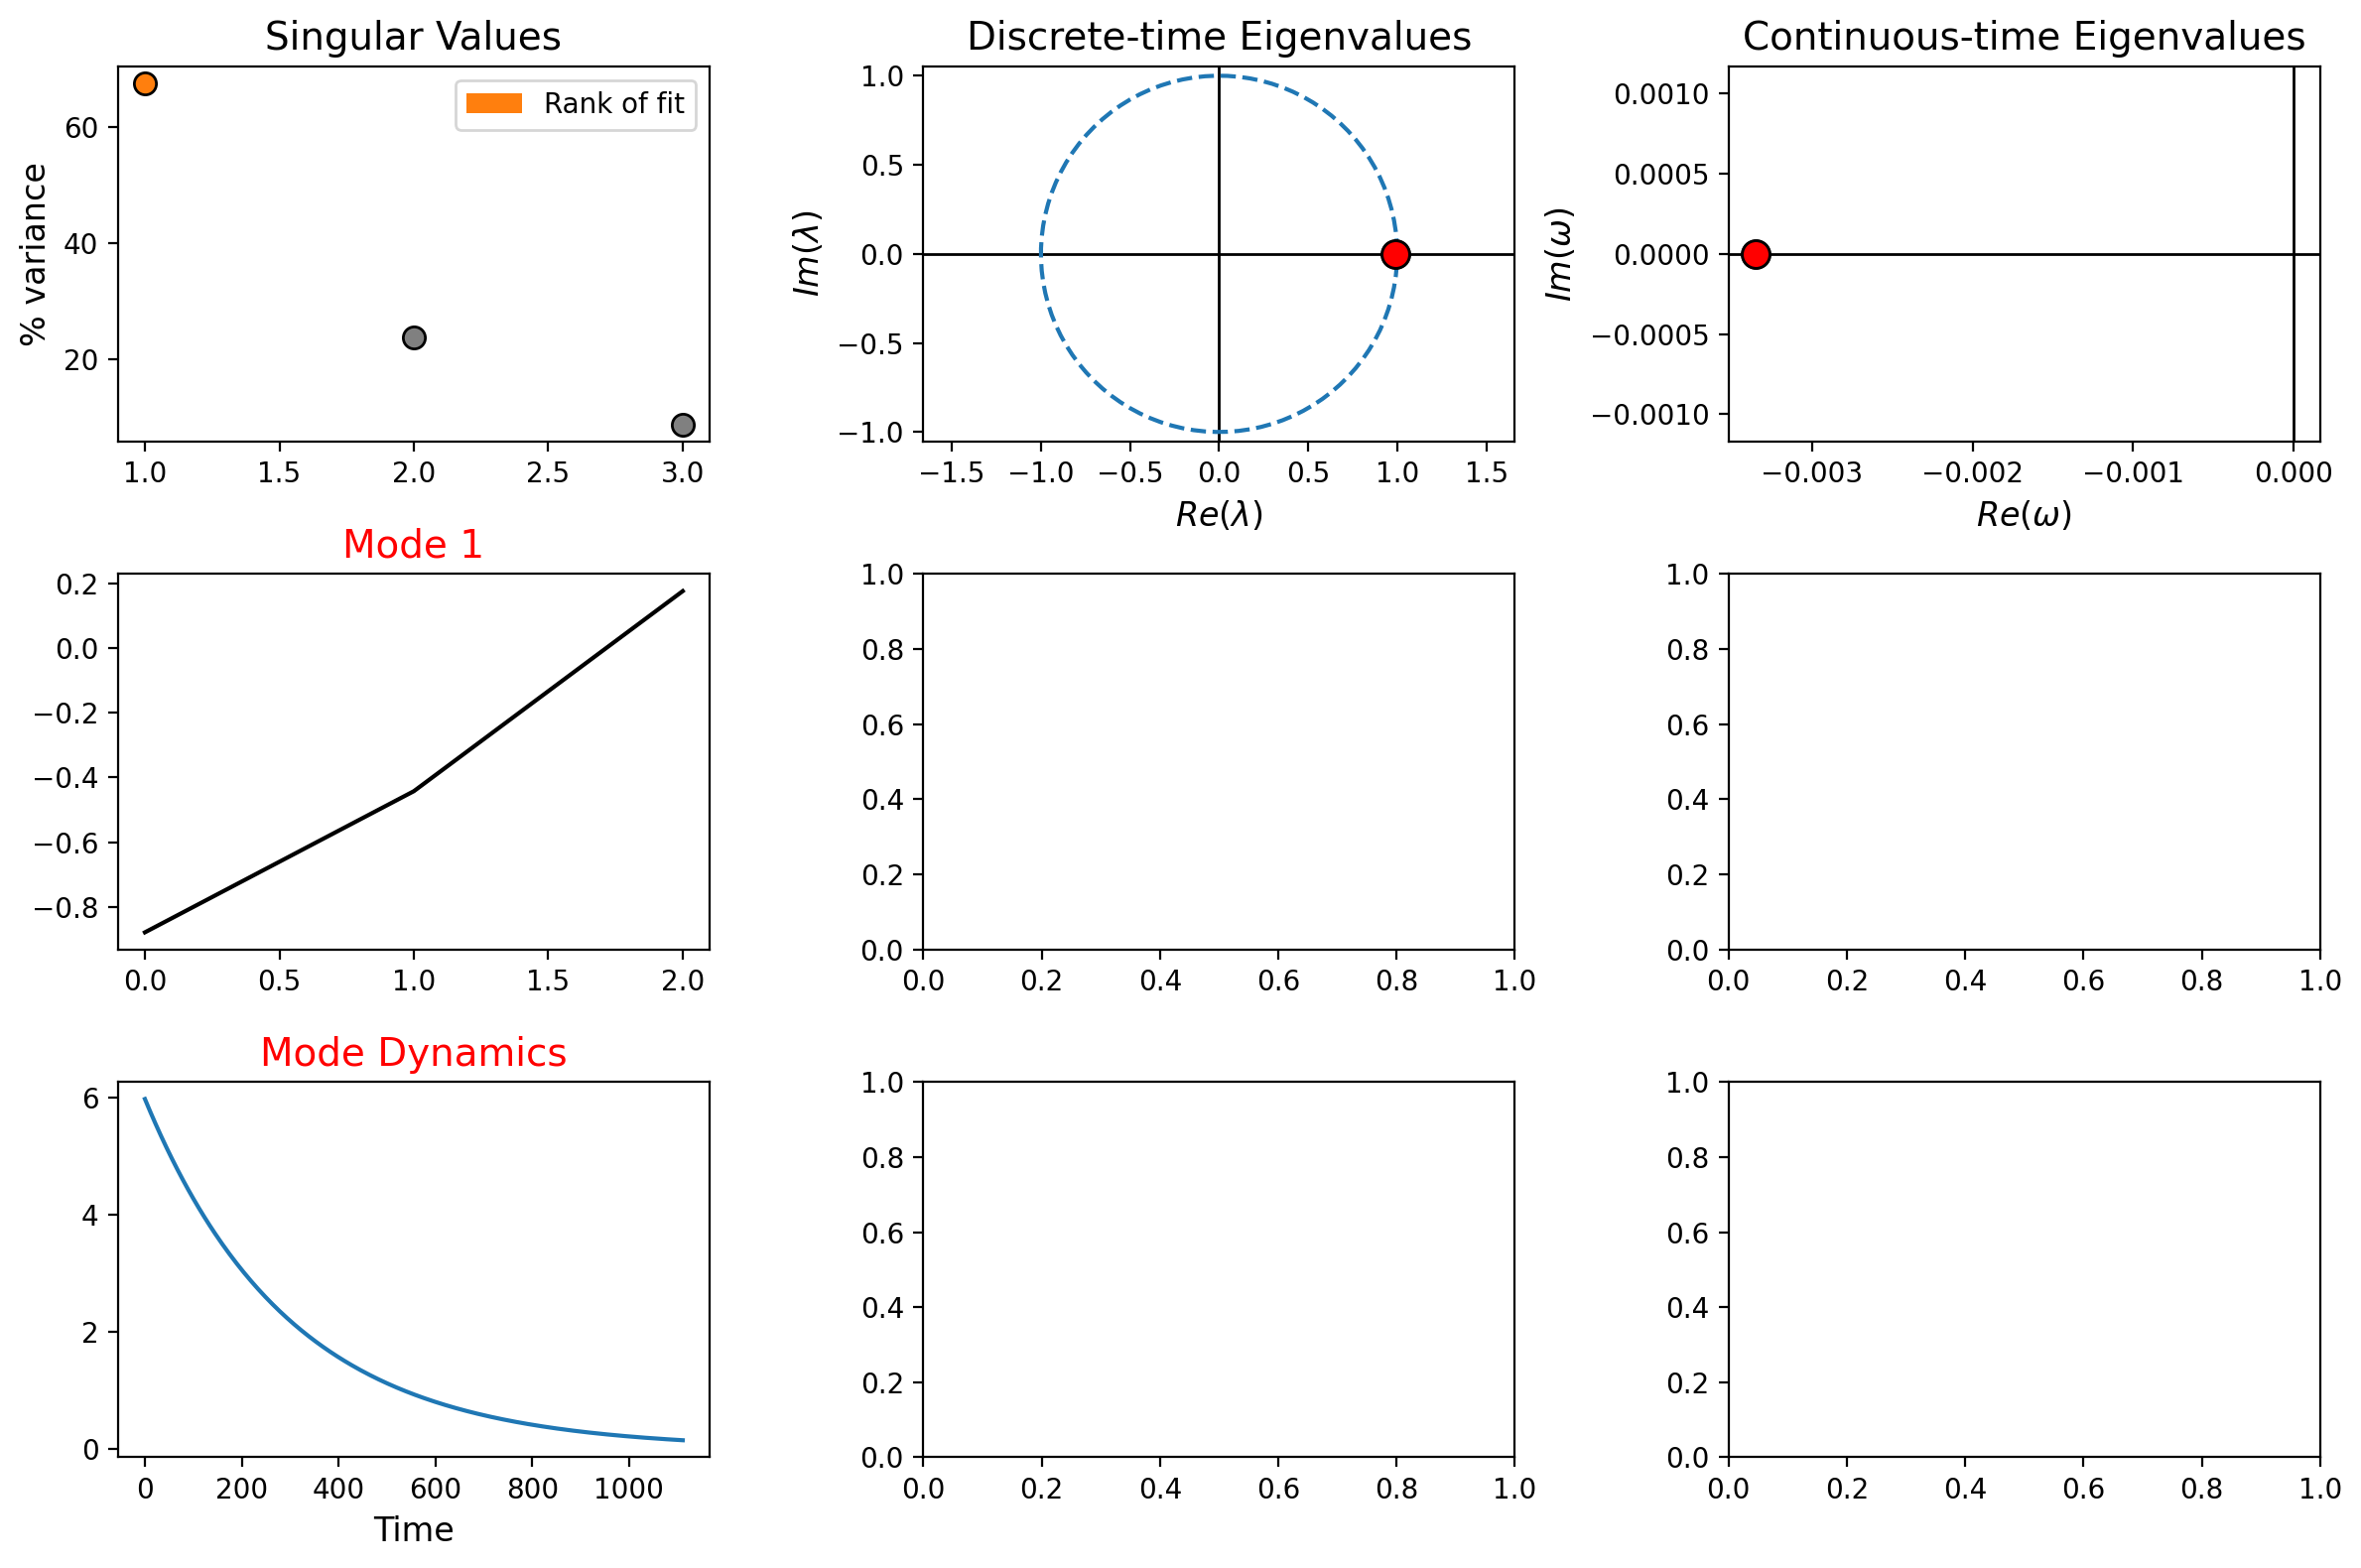

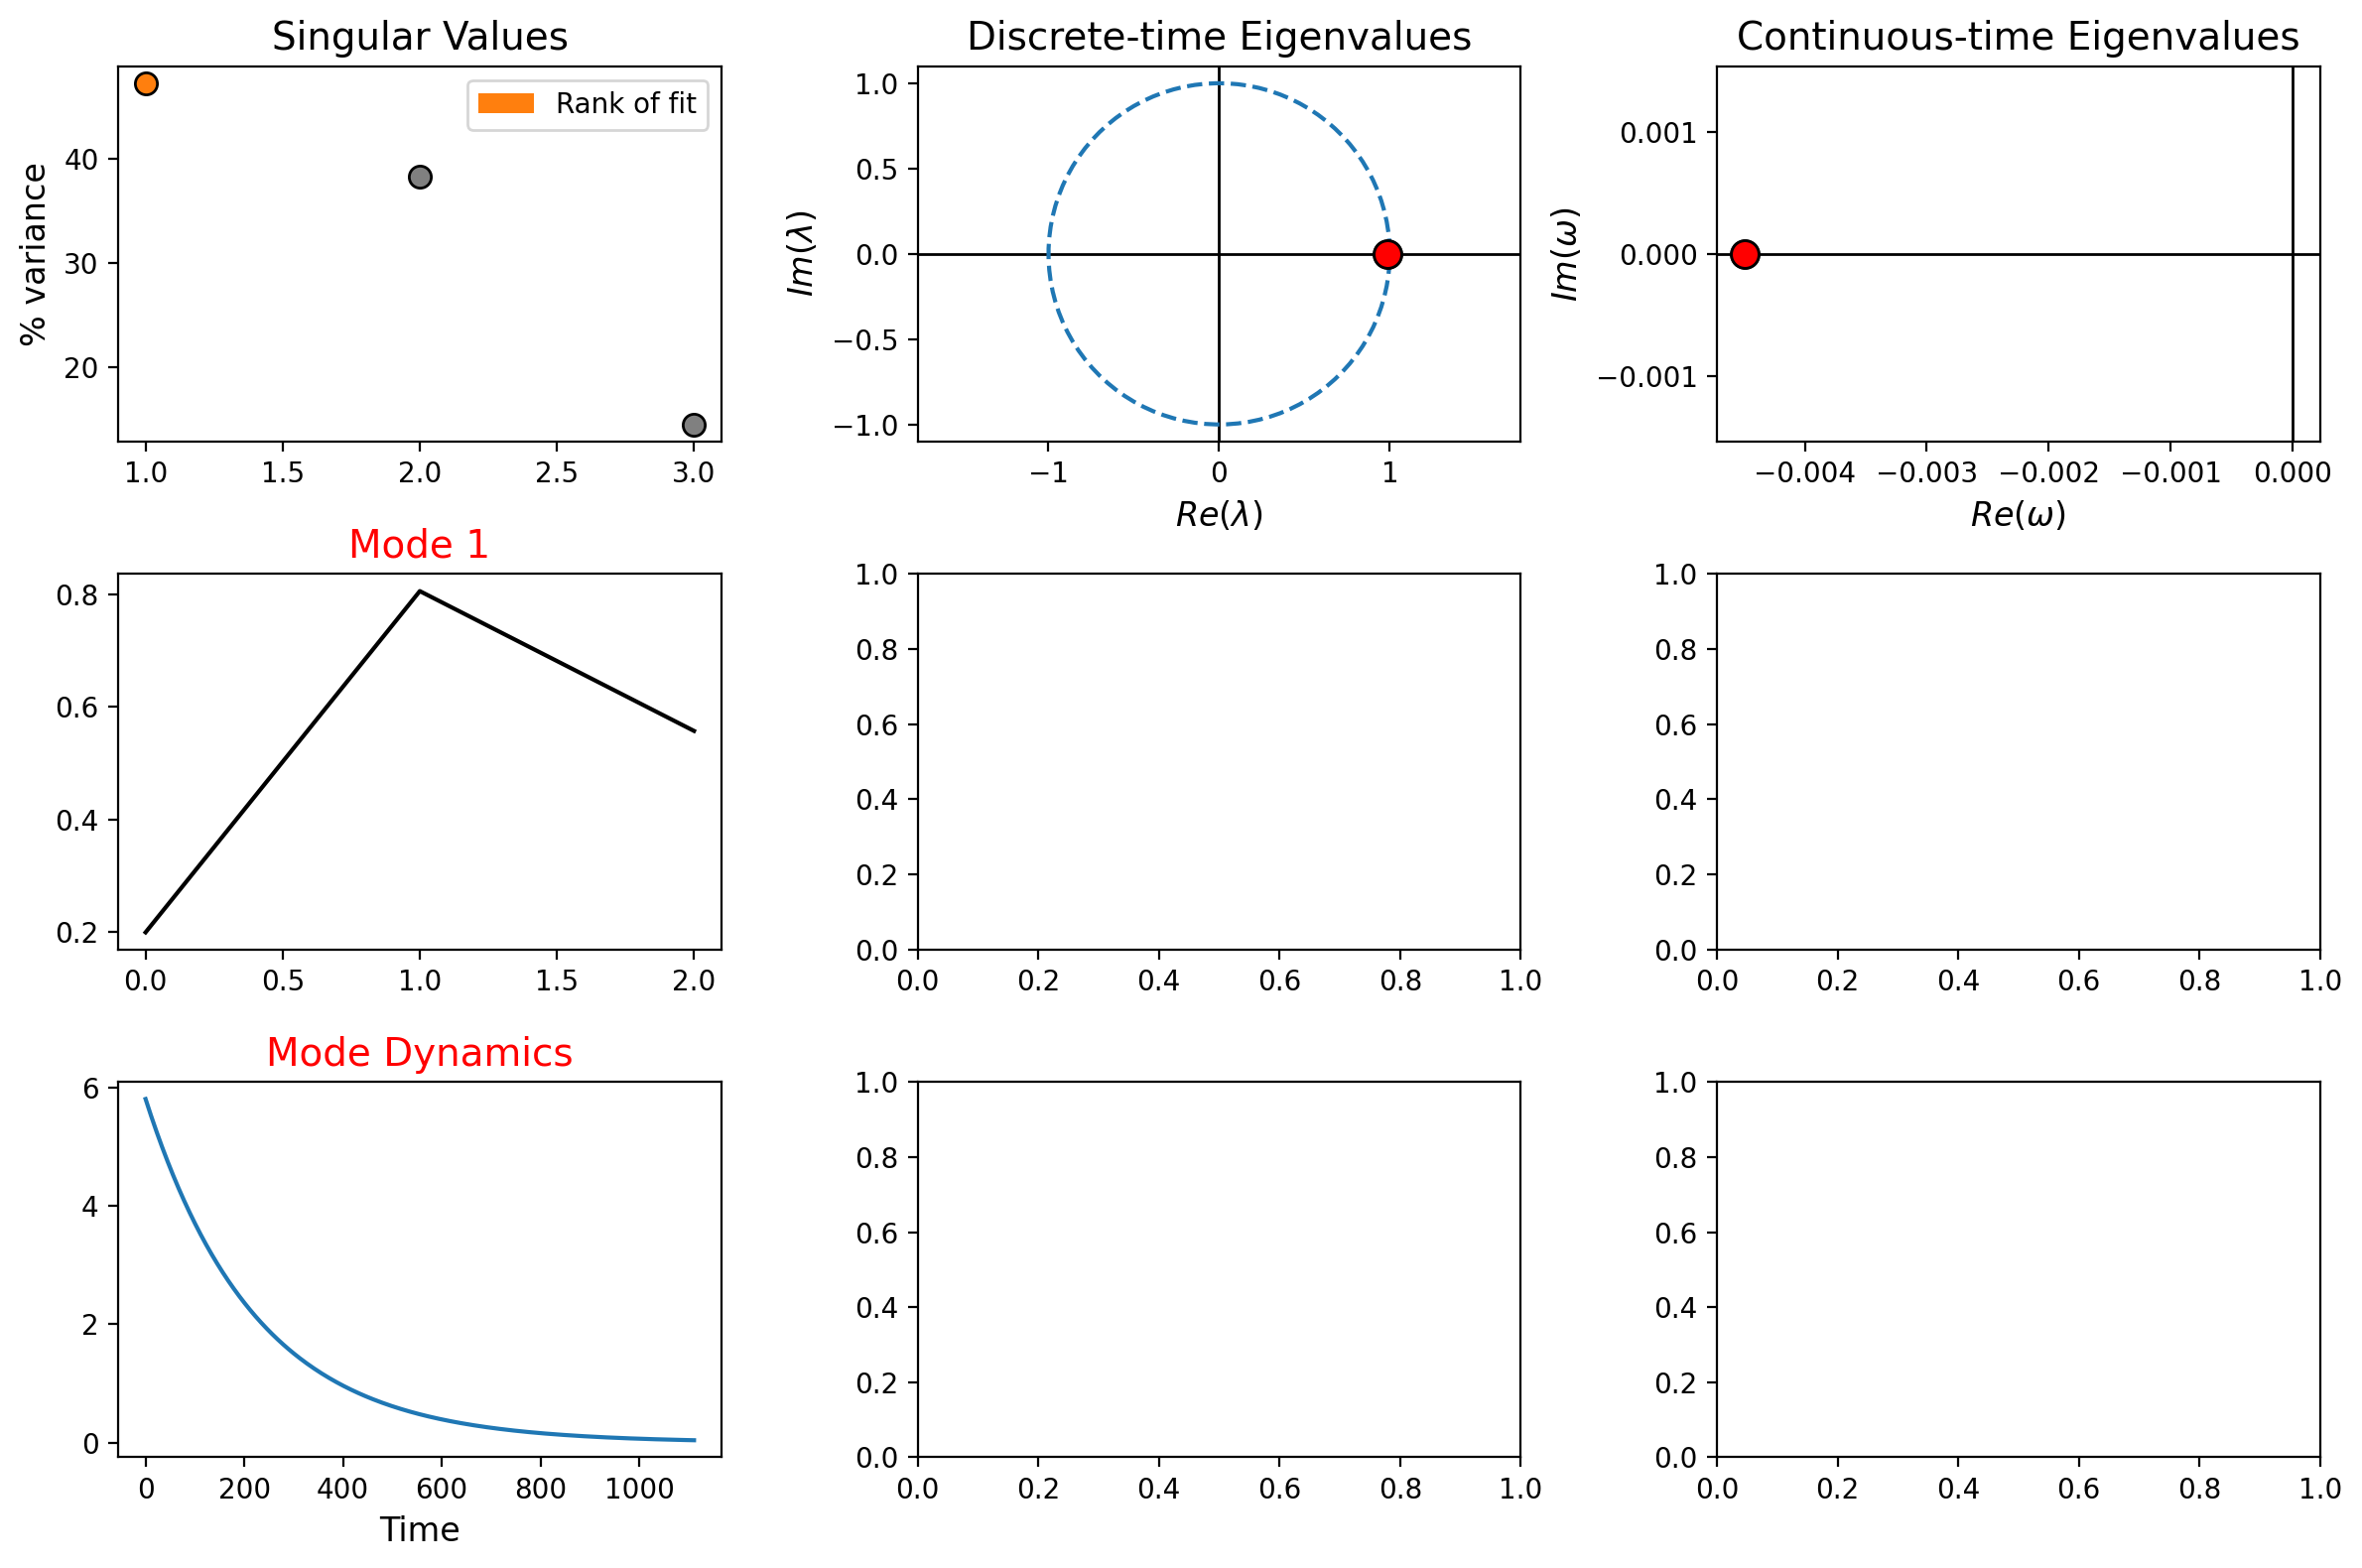

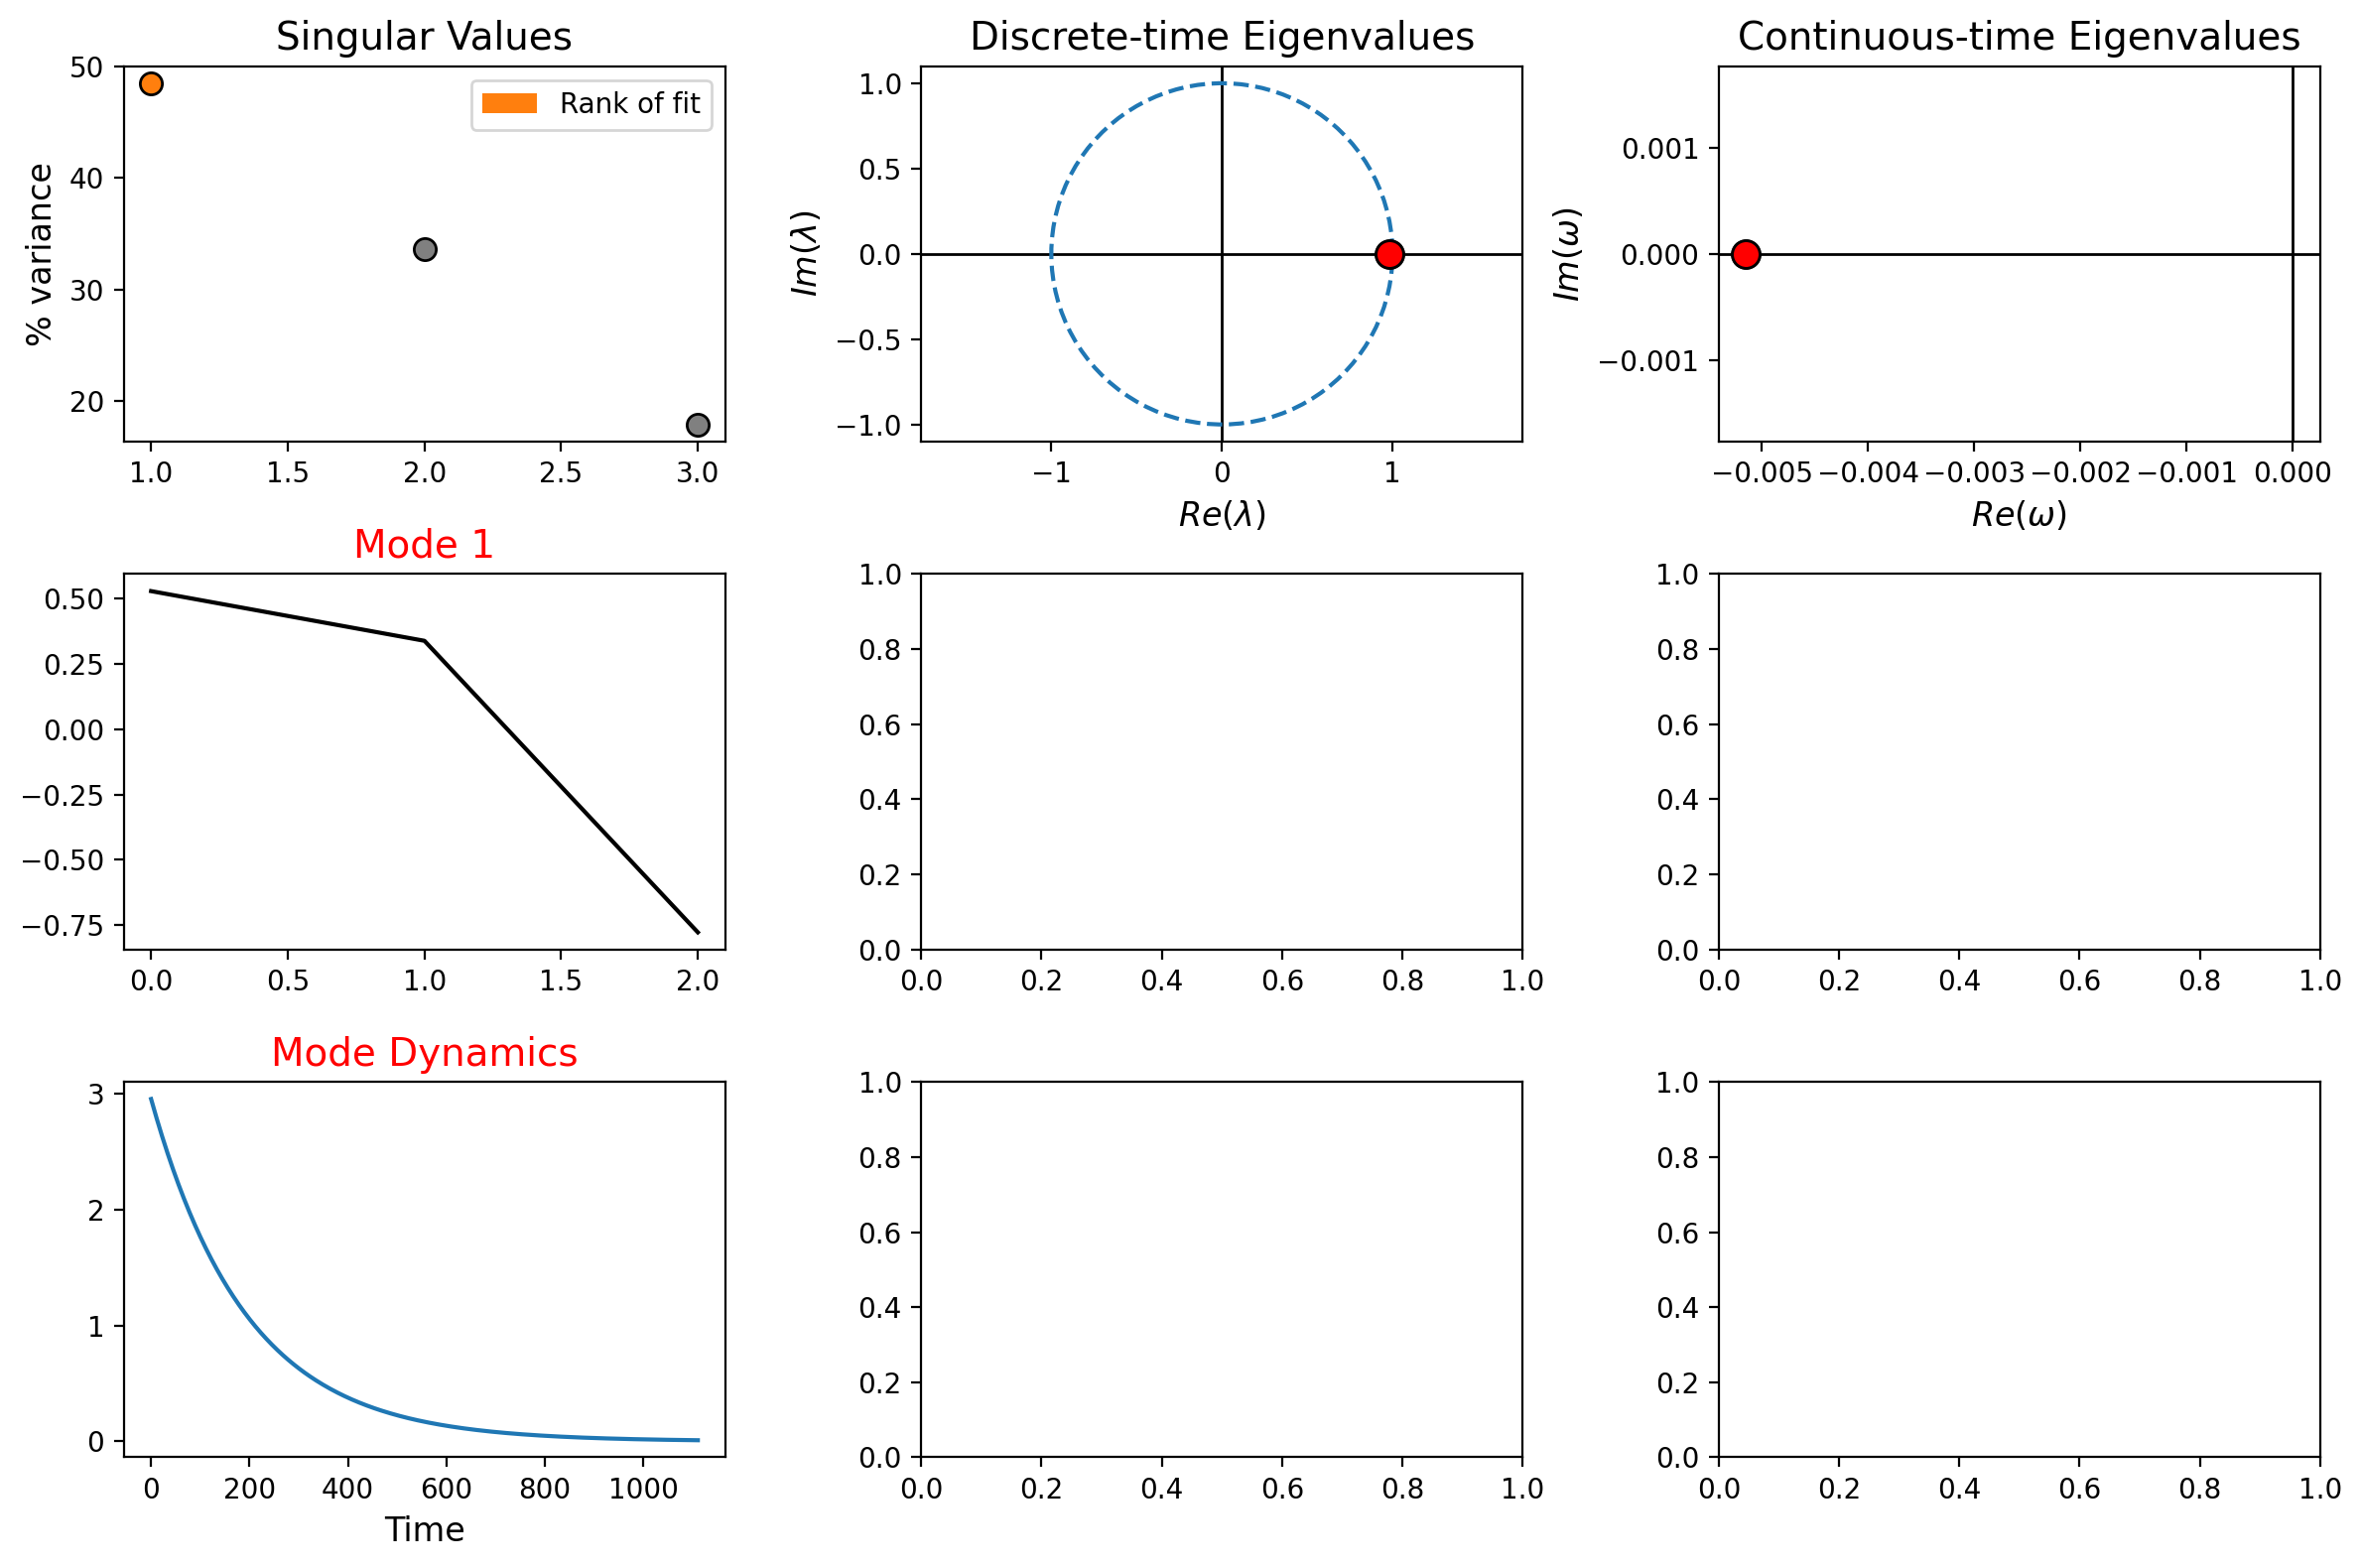

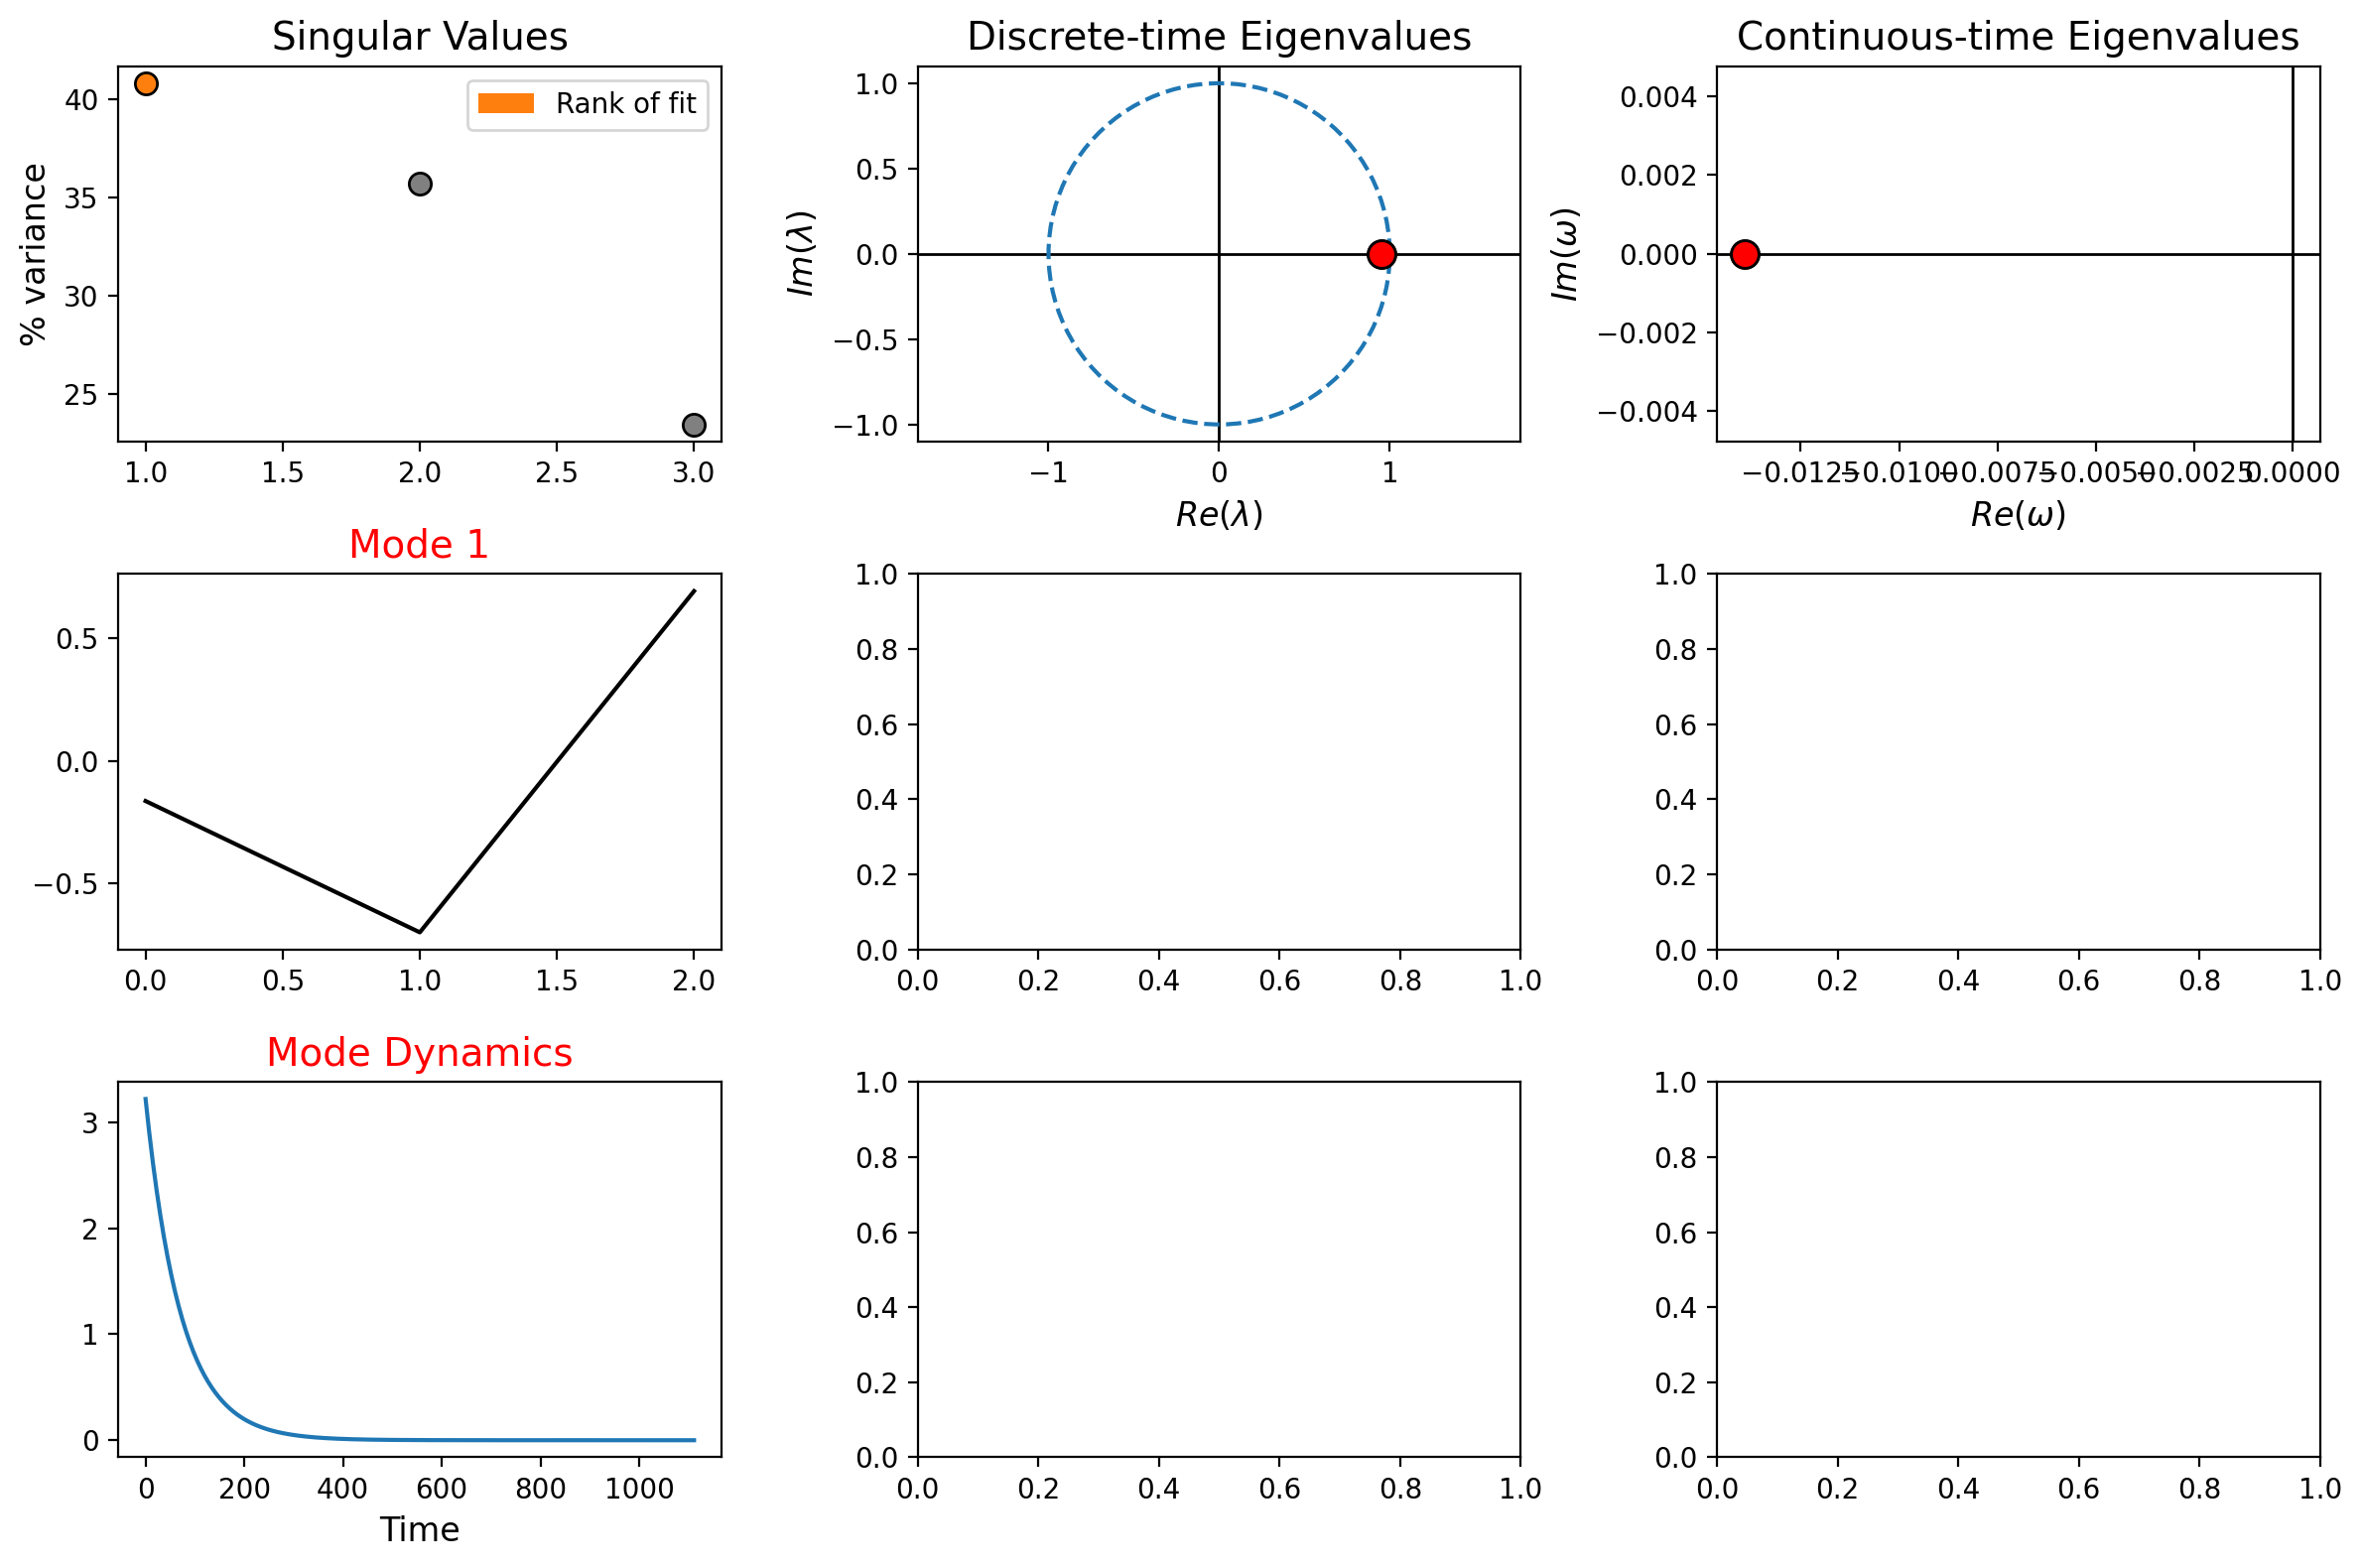

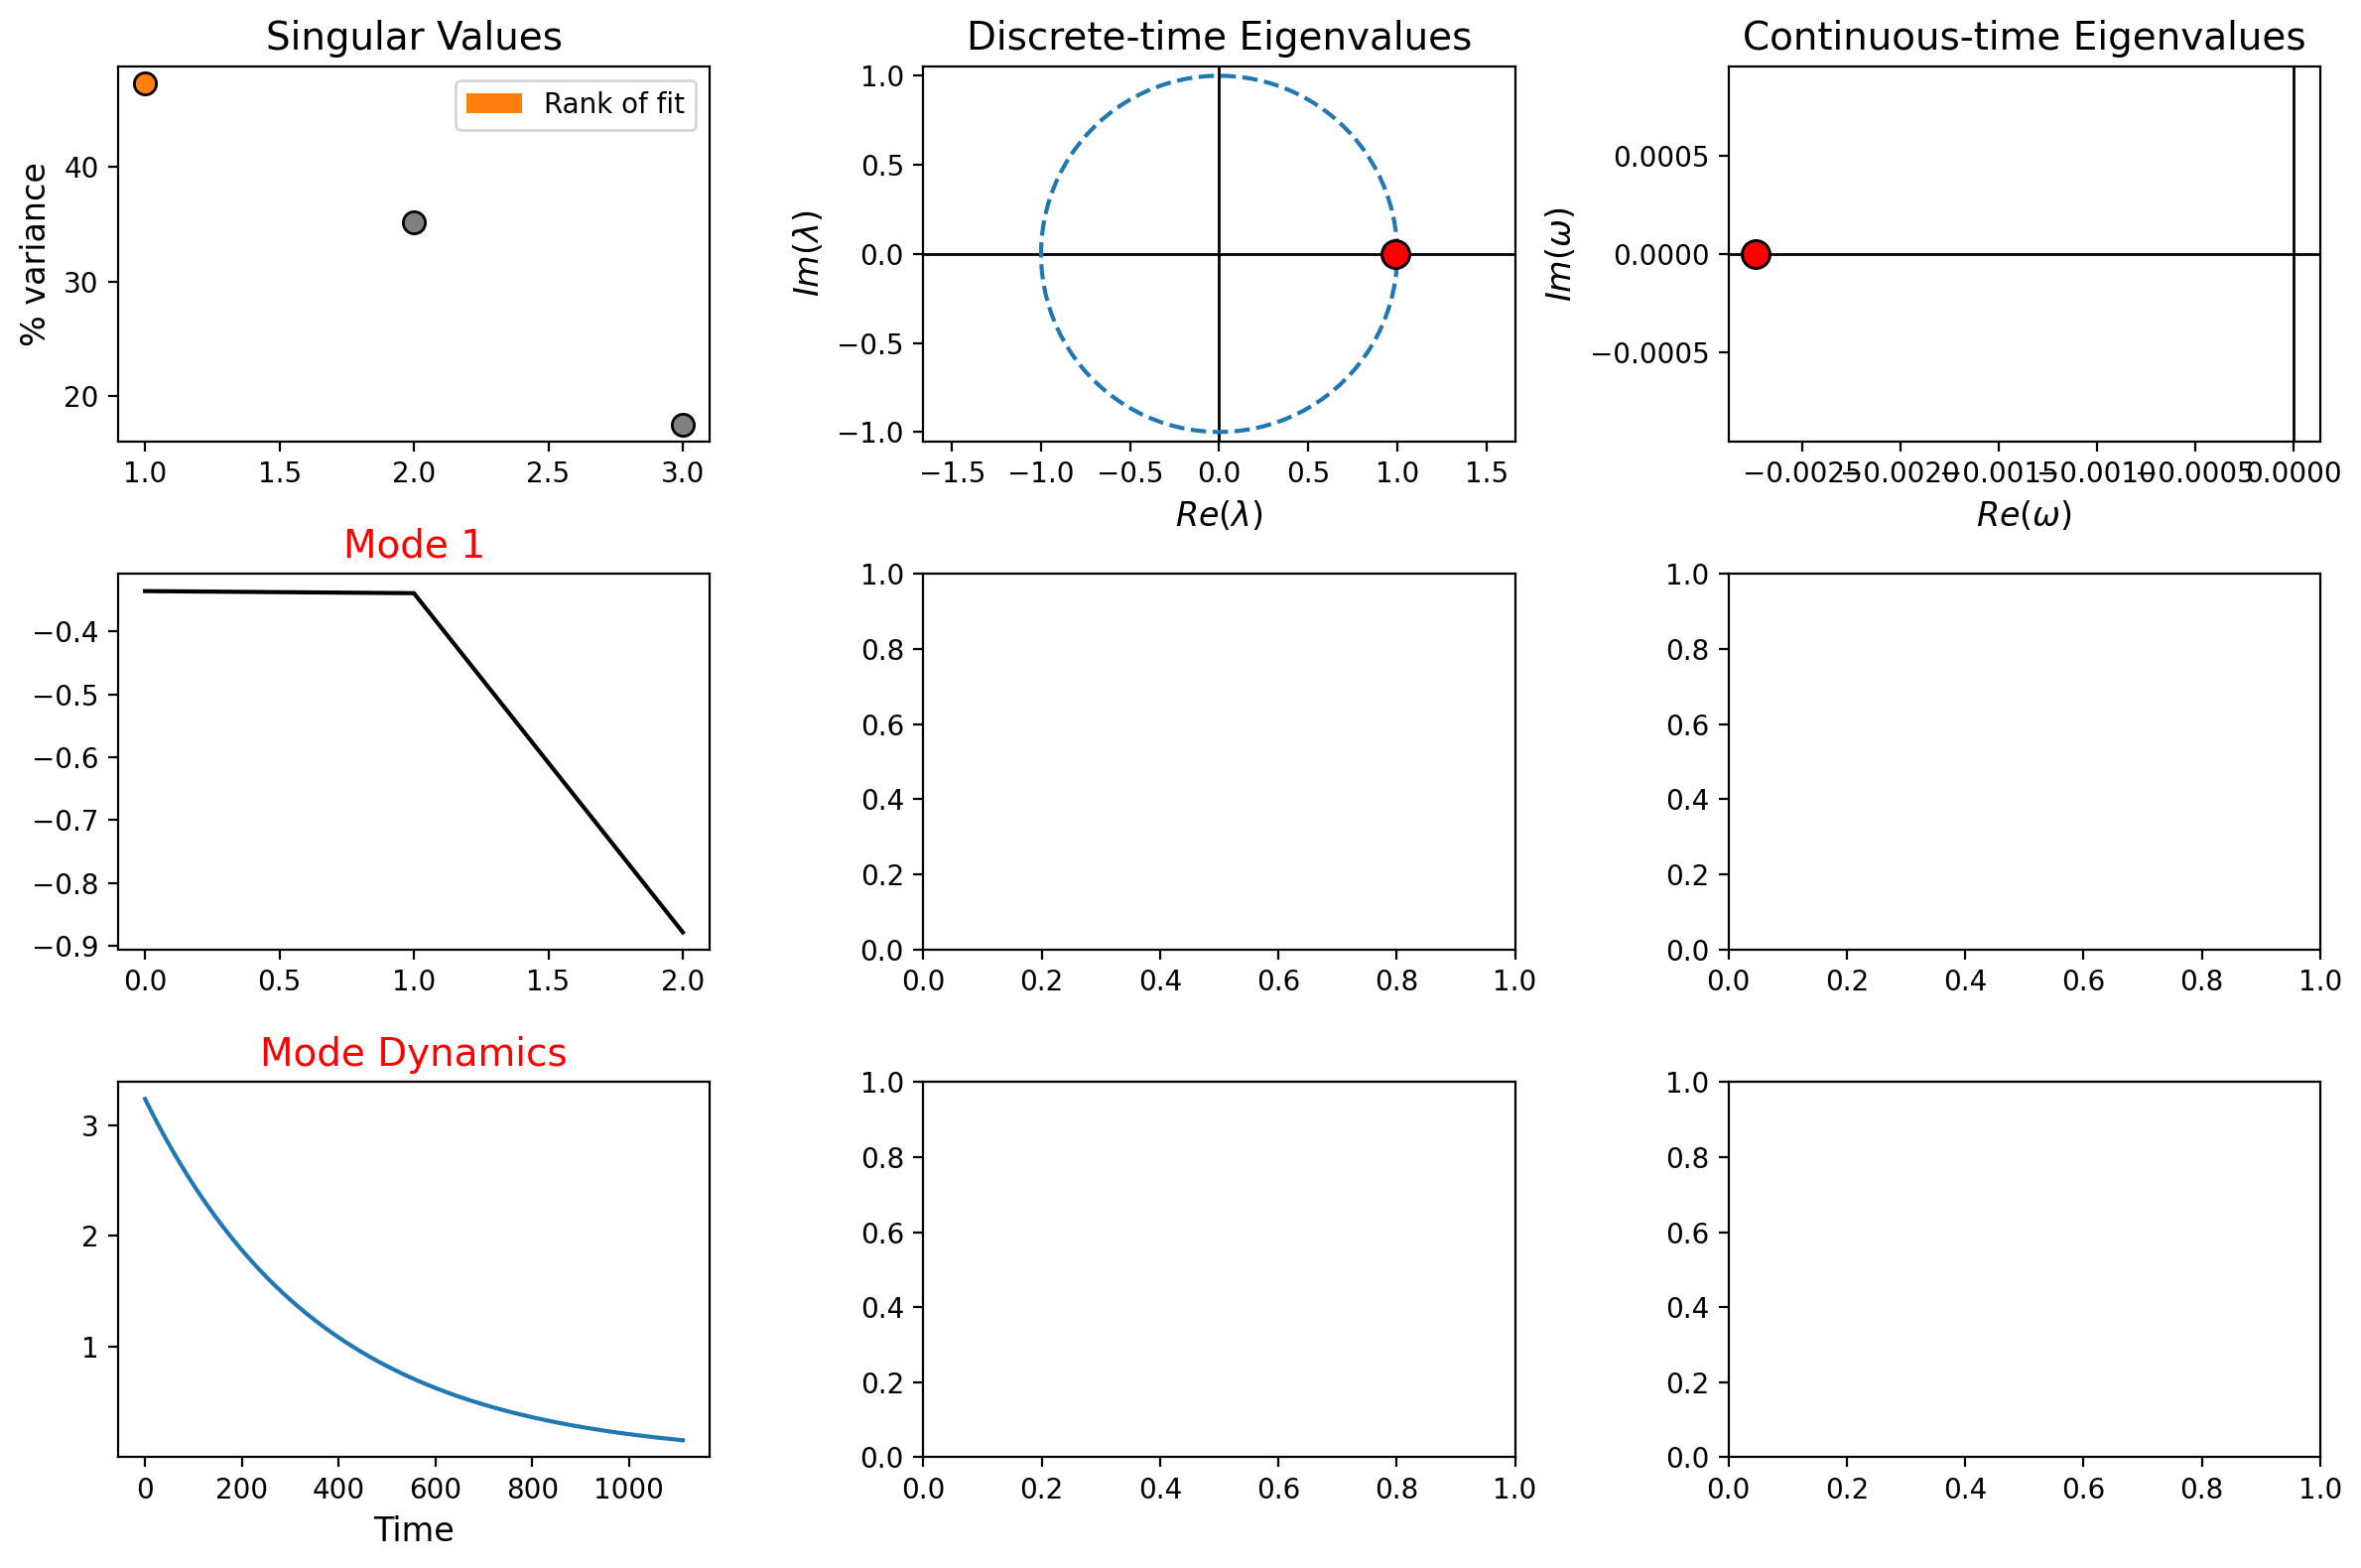

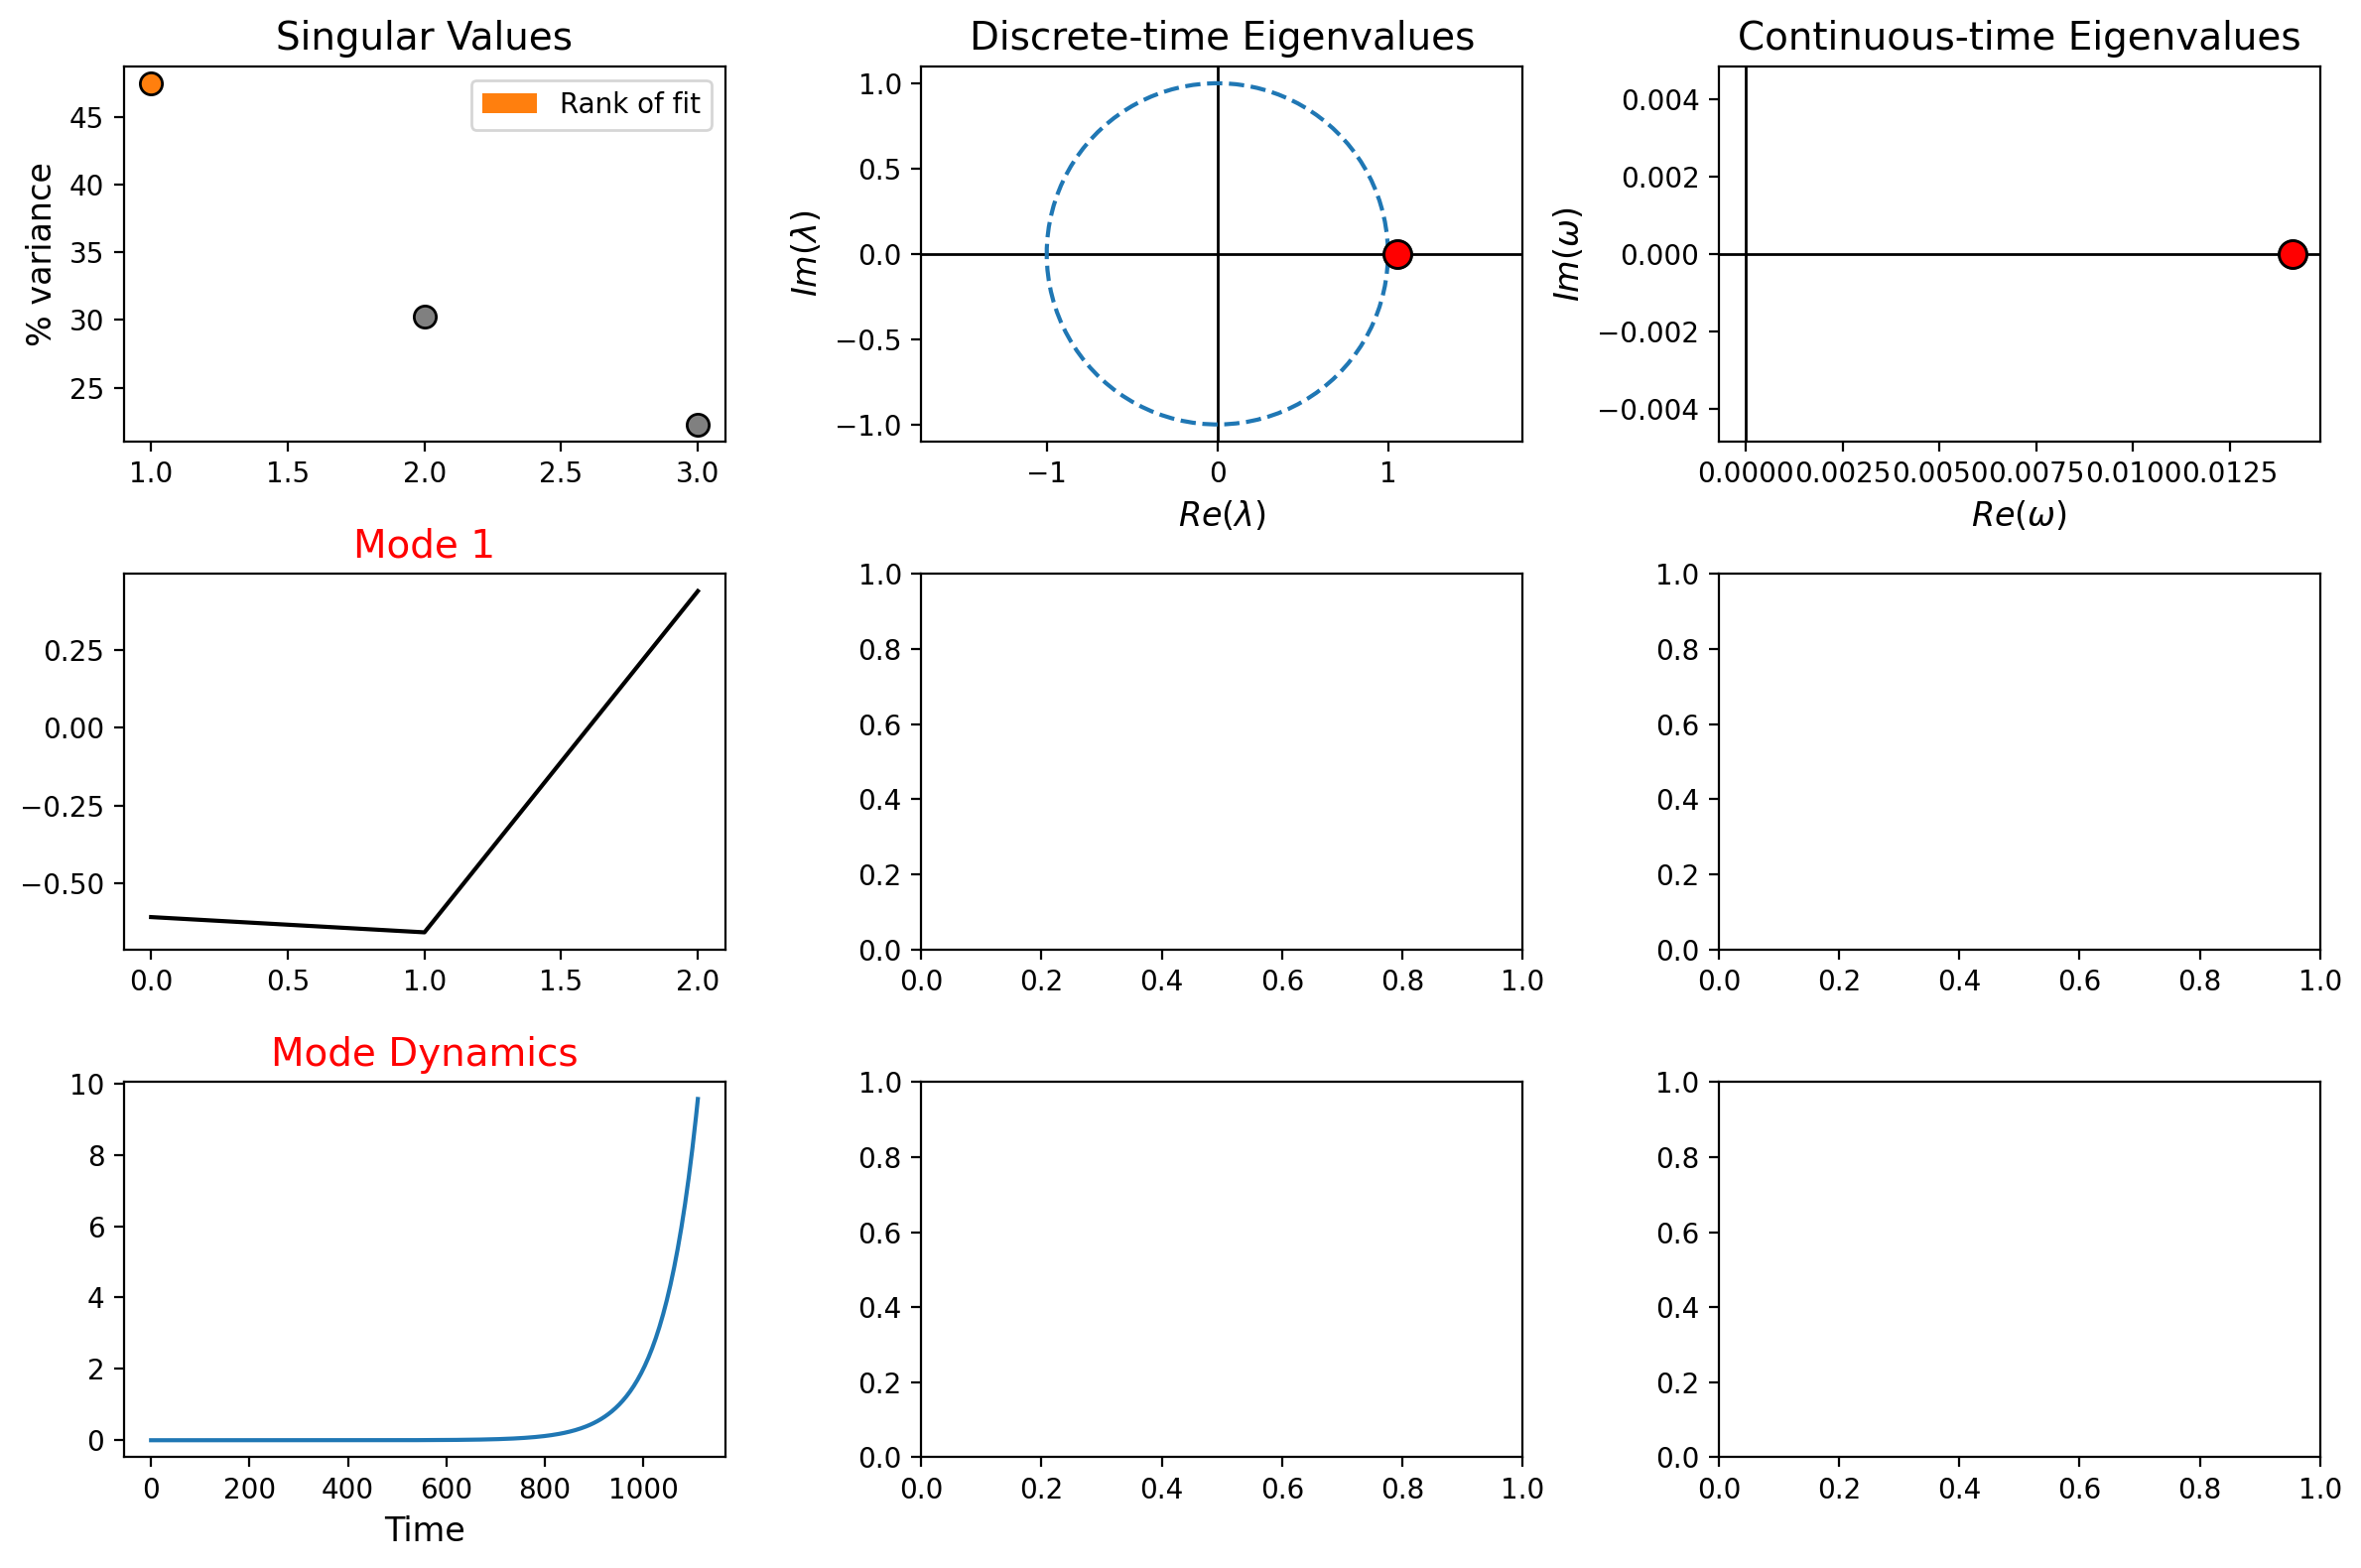

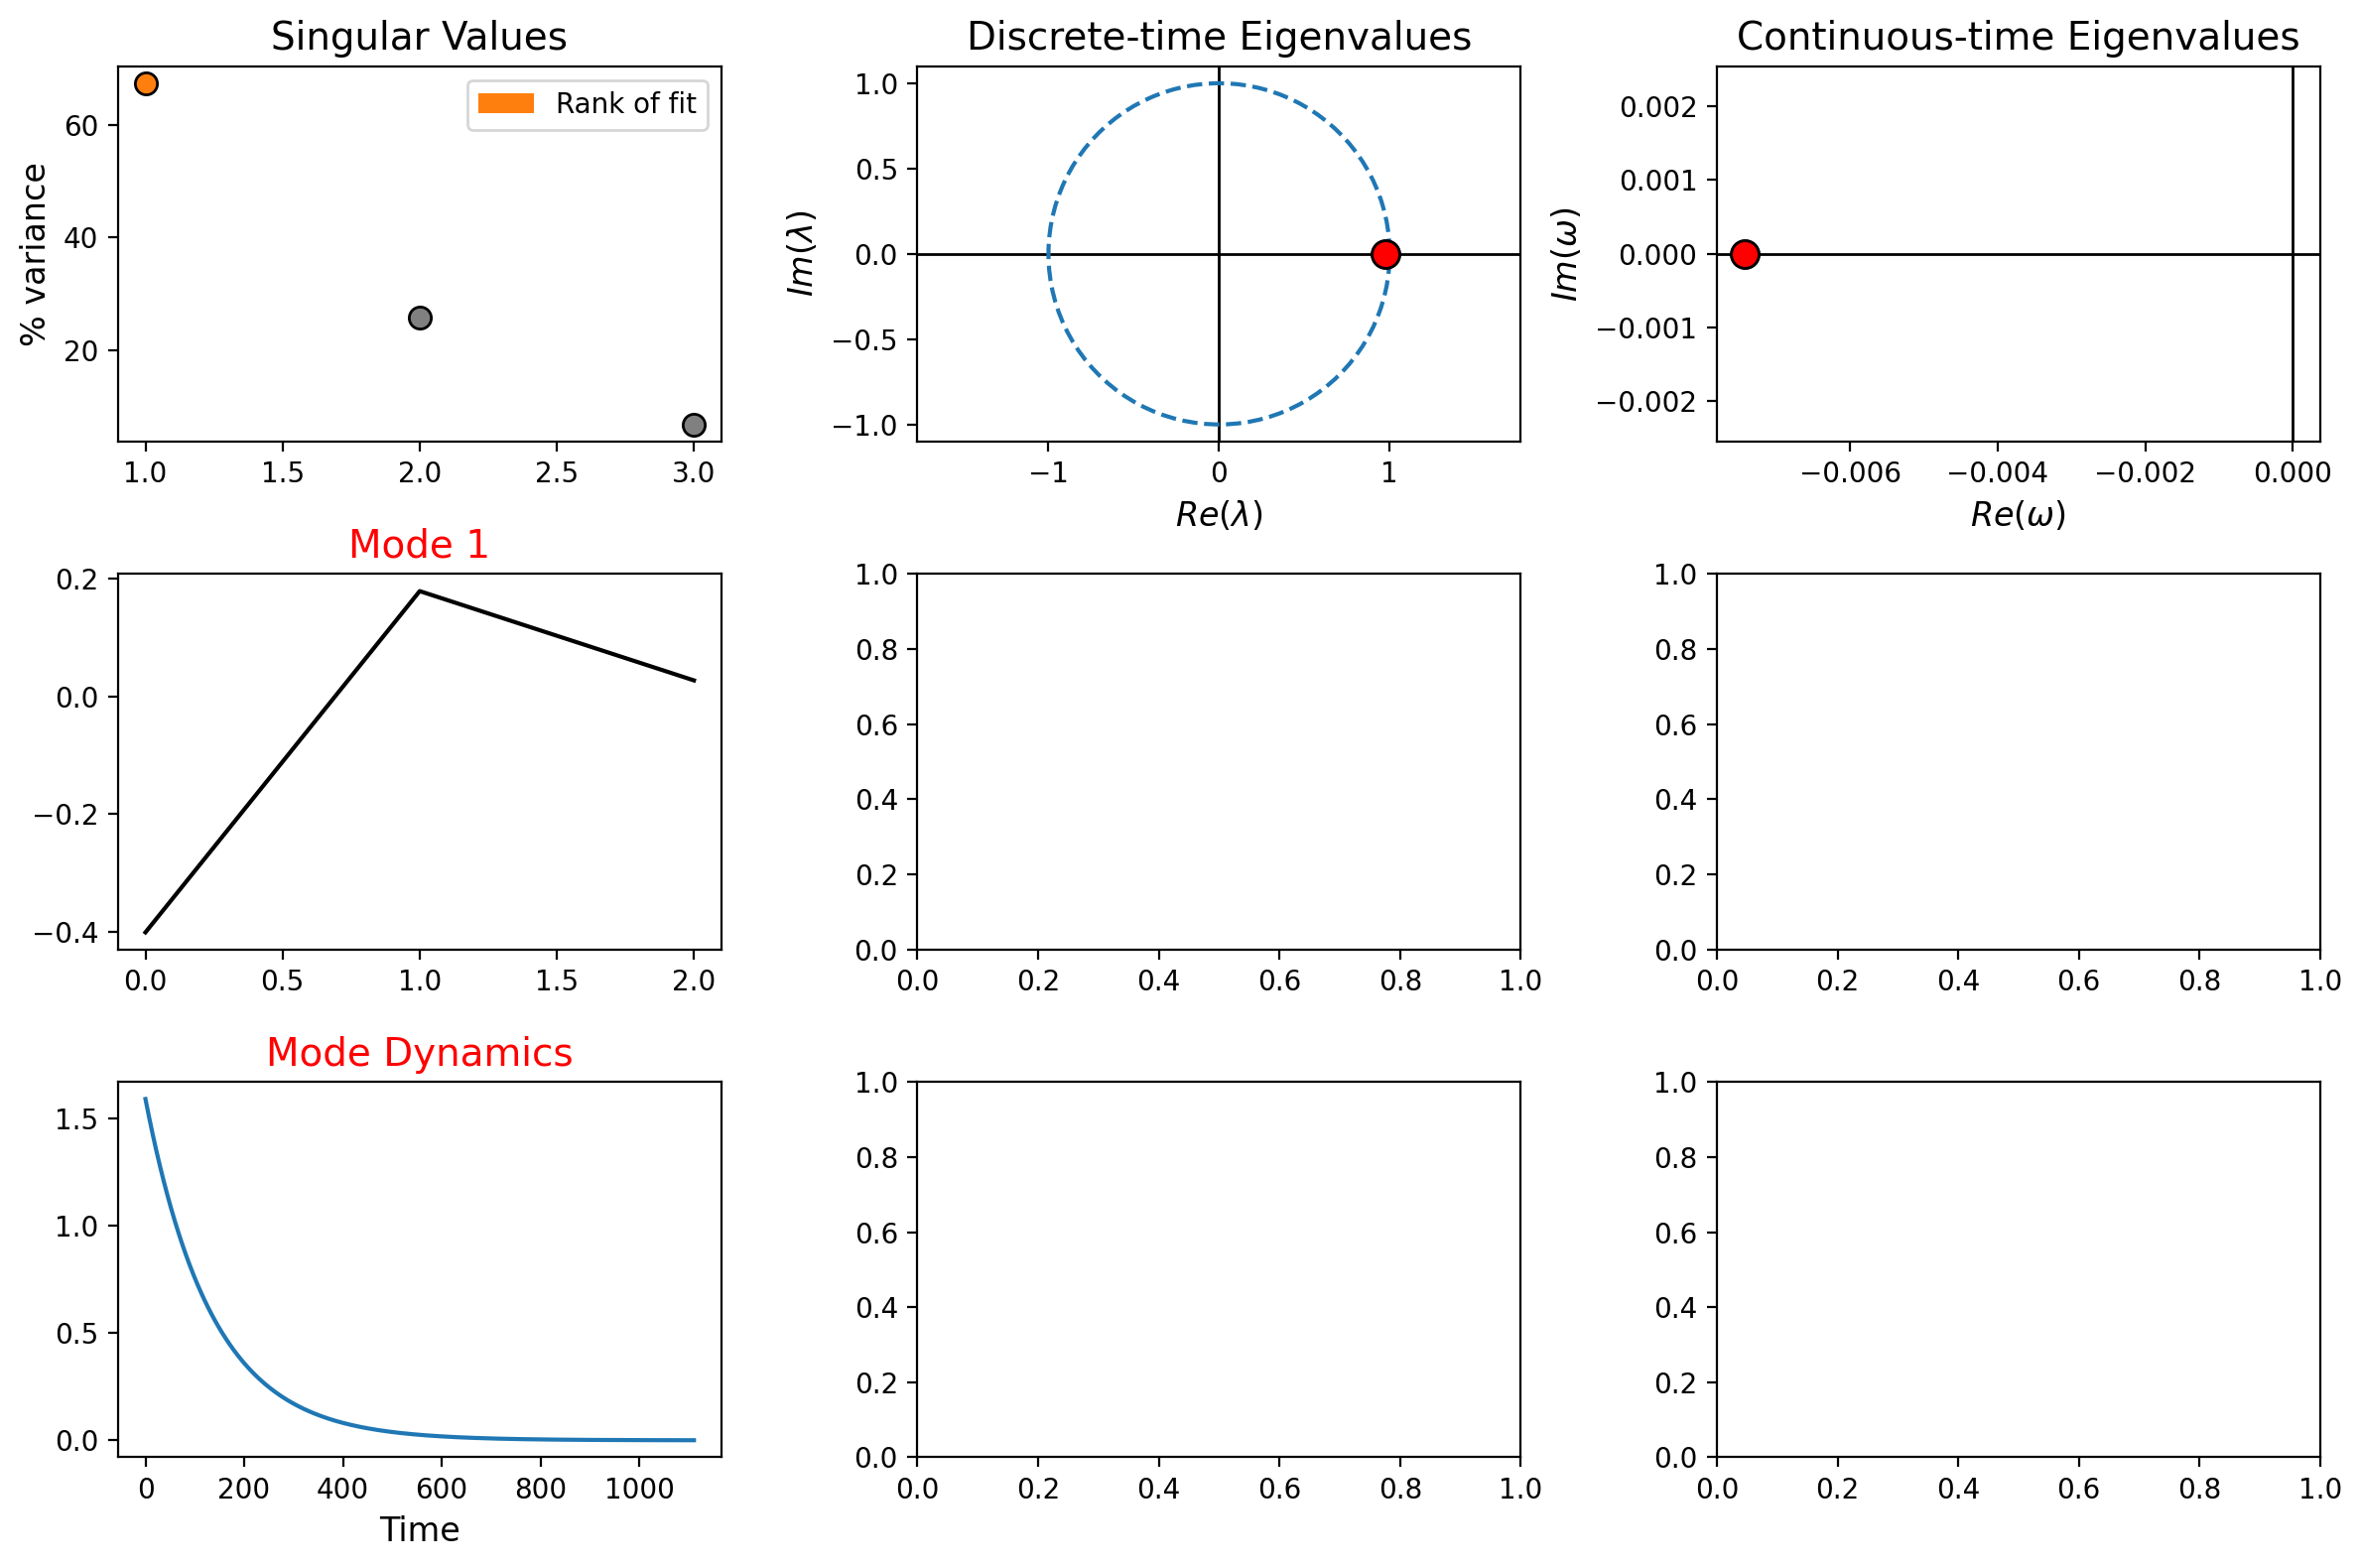

In [26]:
observables = ["a", "b", "c"]
n = len(observables)
n_timesteps = 300
duration = 1111
t = np.linspace(0, duration, n_timesteps)  # (n_timesteps,)

_dmd = Dmd(observables=observables, t=t)
res = _dmd.fit()
res.plot()